# Embryo Diffusion - Next-Frame Prediction

This notebook trains a context-conditioned diffusion model to predict frame `t+1` from the last `k` grayscale frames.

**Conditioning policy in this notebook**
- Conditioning is strictly temporal: context frames only (`k` previous timesteps).
- There is no focal-plane ID conditioning in the model.
- Training still uses sequences from all focal planes by building independent `(embryo, plane)` streams.

**What is saved each epoch**
- `diffusion_samples/epoch_XX/mixed`
- `diffusion_samples/epoch_XX/transitions`
- `diffusion_samples/epoch_XX/rollouts`


## Notebook Map
1. **Configuration & paths** — all hyperparameters and directory roots.
2. **Imports** — third-party libraries and small utilities.
3. **Reproducibility & label setup** — seeds, device selection, phase label definitions.
4. **Frame index** (cached CSV) — scan silver dataset, build frame→phase table.
   - 4.1 Index caching
5. **Train/val/test splits** by embryo — stratified, cached to CSV.
7. **Diffusion schedules & Model** — DDPM training schedule, DDIM sampling schedule, `DiffusionCond` UNet wrapper with temporal context conditioning.
8. **Image preprocessing & dataset** — center-crop/resize, `PairDataset` (context→target windows with variable-stride augmentation).
   - 8.1 Dataset (Context → Target Windows)
9. **DataLoaders** — train/val/test loaders.
10. **Utilities, Metrics & Sampling Helpers** — model init, optimizer, DDIM sampling (`ddim_sample_from_model`, `sample_from_model`), perceptual metrics, phase classifier.
    - 10.1 Sampling & guidance helpers (model wrappers, CFG DDIM step)
    - 10.2 Perceptual metrics — SSIM & LPIPS
    - 10.3 Phase classifier architecture — `EfficientNetV2MGray` (rollout guidance only)
    - 10.4 Classifier helpers & rollout policy — lazy load/unload, phase prediction, `choose_rollout_next_phase`
11. **Training loop**
    - Training state & LR scheduler
    - Logging, EMA & checkpoint helpers
    - Training step & `one_epoch`
    - Validation metrics & fixed row collections
    - Rollout runner & grid saver (`_run_rollout`, `_save_rollout_grid`)
    - 11.1 One-step sample grid helper (`_save_sample_grid`)
    - Main training loop (per-epoch train/val pass, checkpoint saving, sample generation)
12. **Training curves** — load `metric_history.json` and plot loss/rollout/perceptual curves.
13. **Inference helpers** — `predict_next_frame`, `rollout_next_frames`, `visualize_samples`.


## 1. Configuration
This cell defines data roots, model/training hyperparameters, and qualitative-sampling settings.

**Important knobs**
- `FOCAL_PLANES`: planes included in dataset indexing and training streams.
- `CONTEXT_K`: number of context frames used to predict one next frame (VDM §4.2 — larger k gives richer temporal context).
- `USE_EMA`, `EMA_DECAY`: optional exponential moving average of weights for validation, samples, and best checkpoints.
- `CTX_STRIDE_AUGMENT`, `CTX_STRIDE_OPTIONS`: variable-stride context sampling during training. Validation/test always use stride 1.
- `USE_TEMPORAL_ATTN`, `TEMPORAL_ATTN_DIM`, `TEMPORAL_ATTN_HEADS`, `MAX_CTX_DIST`: factorized temporal self-attention blocks injected after every spatial attention layer (VDM §3). Relative frame-distance positional keys allow the encoder to handle variable strides.
- `CFG_UNCOND_DROP_PROB`, `CFG_GUIDANCE_SCALE`: classifier-free guidance (Ho & Salimans, 2022; VDM §2). Context is zeroed for a fraction of training batches; at inference the guided/unconditional predictions are combined.
- `PHASE_POLICY_MODE`, `PHASE_POLICY_ADVANCE_THRESHOLD`: rollout-time phase update policy used during validation and qualitative rollouts when classifier conditioning is enabled.
- `COMPUTE_VAL_ROLLOUT_METRICS`, `VAL_ROLLOUT_STEPS`, and `VAL_ROLLOUT_SAMPLES`: fixed rollout-validation settings.


In [1]:
# ==== CONFIG (edit as needed) ====
from pathlib import Path
import os

DEBUG_MODE = False
VERBOSE = True

# Project root resolution
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != 'diffusion' and (PROJECT_ROOT / 'diffusion').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'diffusion'

# Data roots
DATA_ROOT = PROJECT_ROOT.parent / 'data'
SILVER_ROOT = DATA_ROOT / 'embryo_dataset_silver'
FOCAL_PLANES = ['F0']
FOCAL_PLANE_SET = set(FOCAL_PLANES)
TARGET_PLANE = 'F0'

# Context window for next-frame prediction (VDM §4.2: larger k gives richer temporal context)
CONTEXT_K = 4
MODEL_CONTEXT_K = CONTEXT_K
MODEL_OUT_CHANNELS = 1  # always predict one grayscale next frame

# Time conditioning (absolute frame-index spatial map)
USE_TIME_MAP = True
MAX_FRAME_INDEX = 800
TIME_EMB_DIM = 8

# UNet architecture — channel counts per spatial stage.
# VideoContextUNet: in_channels/frame = MODEL_OUT_CHANNELS + 1 (mask) + int(USE_TIME_MAP)
# All K = CONTEXT_K + 1 frames are batch-expanded through the same UNet backbone (VDM §3).
MODEL_BLOCK_OUT_CHANNELS = (32, 64, 128, 256, 256)
MODEL_LAYERS_PER_BLOCK = 1
MODEL_ARCH_TAG = 'u' + '-'.join(str(ch) for ch in MODEL_BLOCK_OUT_CHANNELS) + f'_lpb{MODEL_LAYERS_PER_BLOCK}'

# VideoContextUNet-specific: temporal attention in the deepest N stages.
N_ATTN_STAGES      = 3   # deepest N UNet stages get spatial + TemporalAttnBlock
TEMPORAL_ATTN_HEADS = 4  # attention heads in each TemporalAttnBlock

# VDM/FDM mask channel (Harvey et al., NeurIPS 2022, §4):
# Each frame gets a binary mask channel: 1 = observed (context), 0 = latent (target).
# Mask is built internally by VideoContextUNet; USE_CONTEXT_MASK kept for reference.
USE_CONTEXT_MASK = True    # always True for VideoContextUNet (VDM §3 + FDM §4 mask channel)
MAX_CTX_DIST     = 64      # max relative frame distance for PairDataset ctx_rel_idx clamping

# Variable context stride:
# During training, context frames are sampled at stride s in CTX_STRIDE_OPTIONS
# (uniform stride across the k frames). Validation/test always use stride 1.
# The stride is encoded as a relative-distance tensor ctx_rel_idx [k] that the
# context encoder uses as positional keys (e.g. stride-2 k=5 -> [10, 8, 6, 4, 2]).
CTX_STRIDE_AUGMENT = True
CTX_STRIDE_OPTIONS = [1, 2, 3, 4]  # sampled uniformly during training

# Outputs
OUT_MODELS_DIR = PROJECT_ROOT / 'embryo_diffusion_models'
OUT_SAMPLES_DIR = PROJECT_ROOT / 'diffusion_samples'
CACHE_DIR = PROJECT_ROOT / 'cache'
for d in (OUT_MODELS_DIR, OUT_SAMPLES_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Classifier — used only for qualitative rollout visualisation (not the training objective).
# DISABLED: existing classifier checkpoints were trained at 256px and are incompatible
# with 128px input. Retrain the classifier at 128px before re-enabling.
USE_CLASSIFIER_PHASE_POLICY = False
PHASE_POLICY_MODE = 'argmax'
CLASSIFIER_MODEL_DIR = PROJECT_ROOT.parent / 'classifier' / 'embryo_phase_models'
CLASSIFIER_CKPT_PATH = CLASSIFIER_MODEL_DIR / 'phase_classifier_f0_f1=643.pth'
if not CLASSIFIER_CKPT_PATH.exists():
    ckpts = sorted(CLASSIFIER_MODEL_DIR.glob('phase_classifier_*.pth'), key=lambda p: p.stat().st_mtime, reverse=True)
    CLASSIFIER_CKPT_PATH = ckpts[0] if ckpts else CLASSIFIER_CKPT_PATH

# Training hyperparameters
IMG_SIZE = 128   # 128px = 4× less spatial compute than 256px → ~1.5h/epoch vs ~6h
BATCH_SIZE = 28
LR = 3e-4
USE_LR_SCHEDULER = True
LR_MIN = 1e-7
LR_WARMUP_EPOCHS = 10  # actual warmup clamped to <=20% of EPOCHS in scheduler setup
LR_WARMUP_START_FACTOR = 0.10
EPOCHS = 1000 if not DEBUG_MODE else 6
GRAD_CLIP = 1.0
NUM_WORKERS = 4

# Exponential moving average of model weights
USE_EMA = True
EMA_DECAY = 0.9995
EMA_UPDATE_AFTER_STEP = 100
EMA_USE_FOR_EVAL = True

# DataLoader stability toggles
TRAIN_DROP_LAST = True
TRAIN_PERSISTENT_WORKERS = True
DATALOADER_PREFETCH_FACTOR = 2

VAL_SPLIT = 0.10
TEST_SPLIT = 0.10
SPLIT_SEED = 42

# Checkpointing / logging
RESUME_TRAINING = True
RUN_STEM = (
    f'nextframe_ctxk{CONTEXT_K}_{IMG_SIZE}px_{MODEL_ARCH_TAG}'
    f'_vdm'
)
LAST_CKPT_PATH          = OUT_MODELS_DIR / f'{RUN_STEM}_last.pt'
BEST_CKPT_PATH          = OUT_MODELS_DIR / f'{RUN_STEM}_best.pt'
BEST_ONE_STEP_CKPT_PATH = OUT_MODELS_DIR / f'{RUN_STEM}_best_one_step.pt'
BEST_ROLLOUT_CKPT_PATH  = OUT_MODELS_DIR / f'{RUN_STEM}_best_rollout.pt'
LOG_PATH                = OUT_MODELS_DIR / f'{RUN_STEM}_log.txt'
METRIC_HISTORY_PATH     = OUT_MODELS_DIR / f'{RUN_STEM}_metric_history.json'

# Diffusion process
TIMESTEPS = 1000
BETA_START, BETA_END = 1e-4, 2e-2

# DDIM sampling — 64 steps saturates DDIM quality; 250 is wasteful
USE_DDIM_SAMPLING = True
DDIM_STEPS = 64
DDIM_ETA = 0.0

# Classifier-free guidance (Ho & Salimans, 2022; VDM §2)
# During training: context channels are zeroed and mask set to 0 with probability
# CFG_UNCOND_DROP_PROB so the model learns an unconditional branch.  During inference:
#   eps_guided = eps_uncond + CFG_GUIDANCE_SCALE * (eps_cond - eps_uncond)
# Higher guidance scale -> sharper / more context-faithful predictions, less diversity.
CFG_GUIDANCE_SCALE  = 3.0   # set to 1.0 to disable guidance at inference
CFG_UNCOND_DROP_PROB = 0.10  # fraction of training samples that see zeroed context + mask=0

# Exposure bias mitigation:
# Primary: Scheduled sampling — replace the most-recent context frame with an
# EMA-model-generated frame, ramping from 0 to SS_PROB_MAX over SS_RAMP_EPOCHS.
# This forces the model to condition on realistic (slightly imperfect) generated
# frames rather than always-perfect ground-truth context.
SS_ENABLED     = False
SS_PROB_MAX    = 0.15   # max probability of replacing newest context frame with EMA pred
SS_RAMP_EPOCHS = 50     # epochs to linearly ramp from 0 to SS_PROB_MAX
SS_DDIM_STEPS  = 20     # fast DDIM used for in-training scheduled sampling generation

# Secondary: small residual Gaussian perturbation (legacy, reduced std).
# Applied after scheduled sampling; mimics minor sensor / quantisation noise.
CONTEXT_PERTURB_PROB      = 0.50   # fraction of training samples whose context is noised
CONTEXT_PERTURB_NOISE_STD = 0.05   # max noise std (reduced from 0.20; SS is primary fix)

# Transition importance weighting: multiply per-sample loss by this factor for windows
# where the target frame crosses a phase boundary (last context phase != target phase).
# Increases gradient signal from rare phase-boundary transitions. Set to 1.0 to disable.
TRANSITION_LOSS_WEIGHT = 3.0

# Rollout CFG scale — lower than CFG_GUIDANCE_SCALE to reduce per-step error compounding.
# At rollout time each step's artefacts are fed as context to the next step, so a high
# guidance scale amplifies errors faster than single-step generation warrants.
ROLLOUT_CFG_SCALE = 2.0

# Speed
# At 128px (B=8, K=5, effective batch=40), peak training VRAM ~1.5-2 GB activations —
# roughly 4× less than 256px. Grad checkpointing is kept on as a safety margin but
# is no longer strictly required at this resolution on 16 GB VRAM.
USE_GRAD_CHECKPOINTING = True
USE_TF32 = True
# torch.compile + enable_gradient_checkpointing() causes graph breaks at every checkpoint
# boundary, splitting the computation into many small subgraphs instead of one optimised
# kernel. On RTX 5080 (Blackwell, sm_12.0) this measured ~10h/epoch vs ~5-6h without compile.
# Disable until a compile-native approach (torch.compile fullgraph=True or selective compile)
# is implemented.
ENABLE_TORCH_COMPILE = False
USE_AMP = True

# Sampling visualisation
SAMPLE_PLANES = list(FOCAL_PLANES)
SAMPLES_PER_PLANE = 1
ENABLE_ROLLOUT_GRIDS = True
ROLLOUT_GRID_STEPS = 3

# Data augmentation (identical transform applied to context and target)
AUGMENT = True
AUGMENT_HFLIP = 0.5
AUGMENT_VFLIP = 0.1
AUGMENT_MAX_ROT = 5.0
AUGMENT_BRIGHTNESS = 0.1
AUGMENT_CONTRAST = 0.1

# Min-SNR loss weighting (Hang et al., 2023)
USE_MIN_SNR = True
MIN_SNR_GAMMA = 5.0

# Prediction parameterisation
# v_prediction: velocity parameterisation (Ho & Salimans, 2022; VDM).
# More numerically stable than epsilon at both high and low noise levels.
# Breaking change from epsilon-trained checkpoints — clear embryo_diffusion_models/ before use.
USE_V_PREDICTION = True

# Validation: offline perceptual metrics (SSIM / LPIPS) — off by default
COMPUTE_VAL_METRICS = False
VAL_METRIC_SAMPLES = 128
VAL_METRIC_MAX_BATCHES = 4
METRIC_SEED = 123

# Rollout validation — kept as an offline diagnostic; NOT used for checkpoint selection
COMPUTE_VAL_ROLLOUT_METRICS = False
VAL_ROLLOUT_STEPS = 3
VAL_ROLLOUT_SAMPLES = 100
VAL_ROLLOUT_BATCH_SIZE = 2    # small batch for rollout eval; each sample costs DDIM_STEPS*H fwd passes

# Phase classifier policy parameters (used in rollout helpers / phase labelling)
PHASE_POLICY_ADVANCE_THRESHOLD = 0.7

# Early stopping
EARLY_STOPPING_PATIENCE = 150

print('Project root:', PROJECT_ROOT)
print('Silver root:', SILVER_ROOT)
print('Focal planes:', FOCAL_PLANES)
print(f'Context window k={CONTEXT_K}  |  img_size={IMG_SIZE}')
print(f'UNet block_out_channels: {MODEL_BLOCK_OUT_CHANNELS}  layers_per_block: {MODEL_LAYERS_PER_BLOCK}')
print(f'Run stem: {RUN_STEM}')
print(f'DDIM: steps={DDIM_STEPS}, eta={DDIM_ETA}')
print(f'Min-SNR: enabled={USE_MIN_SNR}, gamma={MIN_SNR_GAMMA}')
print(f'V-prediction: {USE_V_PREDICTION}')
_in_ch_vcu = MODEL_OUT_CHANNELS + 1 + int(USE_TIME_MAP)
print(f'VideoContextUNet (VDM §3 + FDM §4 mask): {_in_ch_vcu} ch/frame (pixel+mask+timemap), K={CONTEXT_K + 1} frames batch-expanded')
print(f'  n_attn_stages={N_ATTN_STAGES}, temporal_attn_heads={TEMPORAL_ATTN_HEADS}, max_ctx_dist={MAX_CTX_DIST}')
print(f'CFG: guidance_scale={CFG_GUIDANCE_SCALE}, rollout_scale={ROLLOUT_CFG_SCALE}, drop_prob={CFG_UNCOND_DROP_PROB}')
print(f'Scheduled sampling: enabled={SS_ENABLED}, prob_max={SS_PROB_MAX}, ramp_epochs={SS_RAMP_EPOCHS}, ddim_steps={SS_DDIM_STEPS}')
print(f'Context perturbation (residual): prob={CONTEXT_PERTURB_PROB}, noise_std_max={CONTEXT_PERTURB_NOISE_STD}')
print(f'Transition loss weight: {TRANSITION_LOSS_WEIGHT}')
print(f'EMA: enabled={USE_EMA}, decay={EMA_DECAY}')
print(f'Rollout val: enabled={COMPUTE_VAL_ROLLOUT_METRICS}, H={VAL_ROLLOUT_STEPS}, samples={VAL_ROLLOUT_SAMPLES}, batch={VAL_ROLLOUT_BATCH_SIZE}')
print(f'Variable stride: enabled={CTX_STRIDE_AUGMENT}, options={CTX_STRIDE_OPTIONS}')
print(f'Speed: grad_checkpointing={USE_GRAD_CHECKPOINTING}, tf32={USE_TF32}, compile={ENABLE_TORCH_COMPILE}, amp={USE_AMP}')
print(f'Classifier phase policy: enabled={USE_CLASSIFIER_PHASE_POLICY}')
if DEBUG_MODE:
    print('DEBUG_MODE is ON')
for plane in FOCAL_PLANES:
    plane_dir = SILVER_ROOT / plane
    assert plane_dir.exists(), f"Silver {plane} folder not found: {plane_dir}"


Project root: /home/khasion/Projects/thesis/diffusion
Silver root: /home/khasion/Projects/thesis/data/embryo_dataset_silver
Focal planes: ['F0']
Context window k=4  |  img_size=128
UNet block_out_channels: (32, 64, 128, 256, 256)  layers_per_block: 1
Run stem: nextframe_ctxk4_128px_u32-64-128-256-256_lpb1_vdm
DDIM: steps=64, eta=0.0
Min-SNR: enabled=True, gamma=5.0
V-prediction: True
VideoContextUNet (VDM §3 + FDM §4 mask): 3 ch/frame (pixel+mask+timemap), K=5 frames batch-expanded
  n_attn_stages=3, temporal_attn_heads=4, max_ctx_dist=64
CFG: guidance_scale=3.0, rollout_scale=2.0, drop_prob=0.1
Scheduled sampling: enabled=False, prob_max=0.15, ramp_epochs=50, ddim_steps=20
Context perturbation (residual): prob=0.5, noise_std_max=0.05
Transition loss weight: 3.0
EMA: enabled=True, decay=0.9995
Rollout val: enabled=False, H=3, samples=100, batch=2
Variable stride: enabled=True, options=[1, 2, 3, 4]
Speed: grad_checkpointing=True, tf32=True, compile=False, amp=True
Classifier phase polic

In [2]:
# ==== Consolidated review changes (override selected CONFIG values above) ====
# Kept as a separate, clearly-labelled cell so the changes are auditable and easy
# to revert. Fold into the CONFIG cell once validated.

# (1) Classifier-free guidance: lowered 3.0 -> 1.5.
#     Next-frame prediction is near-deterministic, so the unconditional branch is
#     weak and a high guidance scale extrapolates into over-sharpened, contrast-
#     boosted frames that hurt LPIPS / pixel fidelity (see eval review). The eval
#     notebook sweeps CFG to locate the best value per checkpoint.
CFG_GUIDANCE_SCALE = 1.5

# (2) Scheduled sampling: enabled to mitigate autoregressive rollout drift
#     (exposure bias). During training the newest context frame is occasionally
#     replaced by an EMA-generated frame so the model conditions on realistic
#     (slightly imperfect) context rather than always-perfect ground truth.
SS_ENABLED = True

# (3) Residual-target prediction: the model diffuses (target - newest context frame)
#     instead of the target frame directly. Consecutive embryo frames are near-identical,
#     so direct next-frame MSE rewards "copy last + blur"; predicting the residual
#     concentrates the learning signal on the actual frame-to-frame change. Sampling
#     reconstructs frame = newest_context + generated_residual.
#     BREAKING: incompatible with non-residual checkpoints (same weight shapes, different
#     target distribution). The run-stem gets a '_resid' tag so checkpoints stay separate
#     and RESUME cannot load an incompatible model -> start a FRESH run (do not resume the
#     old non-residual checkpoints).
USE_RESIDUAL_PREDICTION = True
if USE_RESIDUAL_PREDICTION and not RUN_STEM.endswith('_resid'):
    RUN_STEM = RUN_STEM + '_resid'
    LAST_CKPT_PATH          = OUT_MODELS_DIR / f'{RUN_STEM}_last.pt'
    BEST_CKPT_PATH          = OUT_MODELS_DIR / f'{RUN_STEM}_best.pt'
    BEST_ONE_STEP_CKPT_PATH = OUT_MODELS_DIR / f'{RUN_STEM}_best_one_step.pt'
    BEST_ROLLOUT_CKPT_PATH  = OUT_MODELS_DIR / f'{RUN_STEM}_best_rollout.pt'
    LOG_PATH                = OUT_MODELS_DIR / f'{RUN_STEM}_log.txt'
    METRIC_HISTORY_PATH     = OUT_MODELS_DIR / f'{RUN_STEM}_metric_history.json'

print(f'Overrides -> CFG_GUIDANCE_SCALE={CFG_GUIDANCE_SCALE}, SS_ENABLED={SS_ENABLED}, '
      f'USE_RESIDUAL_PREDICTION={USE_RESIDUAL_PREDICTION}')
print(f'  RUN_STEM={RUN_STEM}')


Overrides -> CFG_GUIDANCE_SCALE=1.5, SS_ENABLED=True, USE_RESIDUAL_PREDICTION=True
  RUN_STEM=nextframe_ctxk4_128px_u32-64-128-256-256_lpb1_vdm_resid


## 2. Imports and small utilities
The notebook relies on **PyTorch** for training, **diffusers** for the UNet + schedulers, and **LPIPS** for perceptual validation metrics.

In [3]:
# Imports & utils
import copy, shutil
import json, math, random, glob, re, os, hashlib
from contextlib import contextmanager
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto
import matplotlib.pyplot as plt

try:
    import psutil
except Exception:
    psutil = None

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import functional as TF
from torchvision.models import efficientnet_v2_m, efficientnet_v2_s

# Perceptual metric
from lpips import LPIPS

# Diffusers library for UNet and schedulers
from diffusers import UNet2DConditionModel, DDPMScheduler, DDIMScheduler

# AMP (automatic mixed precision) flag
# Set to False to avoid CheckpointError
USE_AMP = torch.cuda.is_available()  # avoid CheckpointError (was True)
print(f'AMP enabled: {USE_AMP}')


# TQDM helper: force ETA/remaining to show consistently
# tqdm.auto picks the notebook-aware widget renderer in Jupyter and falls back
# to the standard terminal renderer otherwise.
TQDM_BAR_FORMAT = "{l_bar}{bar} {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"

def tqdm_bar(iterable, **kwargs):
    """Convenience wrapper with consistent progress-bar formatting."""
    return tqdm_auto(iterable, leave=True, bar_format=TQDM_BAR_FORMAT, **kwargs)


AMP enabled: True


## 3. Reproducibility and label setup
We seed all relevant RNGs for reproducibility, pick the compute device, and define the ordered phase labels used throughout the notebook.

In [4]:
# Initialize seed and device (must be before using PHASE_LABELS in later cells)
def seed_everything(seed=42):
    """Make results reproducible across Python/NumPy/PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

if USE_TF32 and torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')
print(f"TF32 enabled: {USE_TF32 and torch.cuda.is_available()}")

# Ordered list of morphokinetic phase labels (target classes)
# pHB is merged into pEB to match the classifier notebook aliasing.
PHASE_LABELS = ['pPB2','pPNa','pPNf','p2','p3','p4','p5','p6','p7','p8','p9+','pM','pSB','pB','pEB']
PHASE_ALIAS = {
    'pHB': 'pEB',
}

def normalize_phase_label(label: str) -> str:
    p = str(label).strip()
    p = re.sub(r"\s+", "", p)
    if p.startswith('t'):
        p = p.replace('t', 'p', 1)
    return PHASE_ALIAS.get(p, p)

NUM_PHASES = len(PHASE_LABELS)
PHASE_TO_ID = {p: i for i, p in enumerate(PHASE_LABELS)}

# Used only for path parsing/validation in inference helpers.
FOCAL_PLANE_SET = set(FOCAL_PLANES)


Using device: cuda
TF32 enabled: True


## 4. Build a frame index (cached)
We scan the *silver* dataset and build a table of frame paths + phase labels. This is cached to CSV so you do it once.

In [5]:
# Build frame index from all focal planes: phase CSV lives next to frames
# Output columns: embryo_id, plane, frame_num (1-based), path, phase_id
INDEX_CACHE = CACHE_DIR / 'silver_all_planes_frame_index_phase_merged.csv'

def build_index_from_silver():
    rows = []
    # For each focal plane
    for plane in FOCAL_PLANES:
        plane_root = SILVER_ROOT / plane
        embryo_ids = sorted([d.name for d in plane_root.iterdir() if d.is_dir()])
        # For each embryo id included in focal plane
        for eid in tqdm(embryo_ids, desc=f'Indexing {plane}'):
            folder = plane_root / eid
            ann_path = folder / f"{eid}_phases.csv"
            if not ann_path.exists():
                continue
            # Use .jpeg files (silver dataset uses .jpeg)
            img_files = sorted(glob.glob(str(folder / '*.jpeg')))
            if not img_files:
                continue
            # Extract frame numbers from filenames (00037.jpeg → 37)
            frame_numbers = {}
            # For each frame image file
            for f in img_files:
                basename = os.path.basename(f)
                m = re.search(r'(\d+)\.jpeg$', basename)
                if m:
                    frame_num = int(m.group(1))
                    frame_numbers[frame_num] = f
            
            # Parse CSV (phase, start, end) allowing labels like "t9 +"
            def _parse_phase_csv(path: Path):
                spans = []
                with open(path, 'r', encoding='utf-8') as fh:
                    for line in fh:
                        line = line.strip()
                        if not line:
                            continue
                        # normalize delimiters to spaces
                        line = re.sub(r"[;,]", " ", line)
                        line = re.sub(r"\s+", " ", line).strip()
                        m = re.match(r"^(.*?)(\d+)\s+(\d+)$", line)
                        if not m:
                            continue
                        phase_raw = m.group(1).strip()
                        start = int(m.group(2))
                        end = int(m.group(3))
                        spans.append((phase_raw, start, end))
                return spans
            
            def phase_to_id(ph: str):
                ph_norm = normalize_phase_label(ph)
                if ph_norm not in PHASE_TO_ID:
                    raise ValueError(f"Unknown phase label after normalization: {ph_norm}")
                return PHASE_TO_ID[ph_norm]

            label_spans = []
            for phase_raw, start, end in _parse_phase_csv(ann_path):
                try:
                    pid = phase_to_id(phase_raw)
                    label_spans.append((int(start), int(end), pid))
                except Exception:
                    pass
            # assign phase per frame using actual frame numbers from filenames
            for frame_num, path in frame_numbers.items():
                pid = None
                for s, e, p in label_spans:
                    if s <= frame_num <= e:  # frame_num is 1-based, matches CSV
                        pid = p
                        break
                if pid is None:
                    continue
                rows.append({'embryo_id': eid, 'plane': plane, 'frame_num': frame_num, 'path': path, 'phase_id': pid})
    return pd.DataFrame(rows)

### 4.1 Index caching
We cache the full frame index to speed up restarts. Delete the cache file if you change the dataset layout.

In [6]:
if INDEX_CACHE.exists():
    index_df = pd.read_csv(INDEX_CACHE)
else:
    index_df = build_index_from_silver()
    index_df.to_csv(INDEX_CACHE, index=False)

print('Indexed frames (full):', len(index_df))
print('Planes:', sorted(index_df['plane'].unique().tolist()))

# Build the nested frame_index dict consumed by PairDataset.
# Structure: frame_index[plane][embryo_id] → {frame_paths, frame_numbers, phase_labels}
frame_index: dict = {}
for (plane, eid), grp in index_df.sort_values('frame_num').groupby(['plane', 'embryo_id'], sort=False):
    frame_index.setdefault(plane, {})[eid] = {
        'frame_paths':   grp['path'].tolist(),
        'frame_numbers': grp['frame_num'].astype(int).tolist(),
        'phase_labels':  grp['phase_id'].astype(int).tolist(),
    }
n_embryos = sum(len(v) for v in frame_index.values())
print(f'frame_index: {len(frame_index)} plane(s), {n_embryos} embryo-plane sequences')

index_df.head()


Indexed frames (full): 289675
Planes: ['F0']
frame_index: 1 plane(s), 703 embryo-plane sequences


,embryo_id,plane,frame_num,path,phase_id
0,AA83-7,F0,5,/home/khasion/Projects/thesis/data/embryo_data...,0
1,AA83-7,F0,6,/home/khasion/Projects/thesis/data/embryo_data...,0
2,AA83-7,F0,7,/home/khasion/Projects/thesis/data/embryo_data...,0
3,AA83-7,F0,8,/home/khasion/Projects/thesis/data/embryo_data...,0
4,AA83-7,F0,9,/home/khasion/Projects/thesis/data/embryo_data...,0


## 5. Train/val/test splits (by embryo)
We split **by embryo ID**, not by frame, to avoid leaking information across sets. Splits are cached on disk.

In [7]:
# Build embryo splits (no embryo appears in more than one split)
SPLIT_CACHE_STEM = (
    f"splits_embryo_phase_ctxk{CONTEXT_K}_"
    f"seed{SPLIT_SEED}_v{VAL_SPLIT}_t{TEST_SPLIT}"
    + ("_debug" if DEBUG_MODE else "")
)
TRAIN_SPLIT_CACHE = CACHE_DIR / f"{SPLIT_CACHE_STEM}_train.csv"
VAL_SPLIT_CACHE = CACHE_DIR / f"{SPLIT_CACHE_STEM}_val.csv"
TEST_SPLIT_CACHE = CACHE_DIR / f"{SPLIT_CACHE_STEM}_test.csv"

def stratified_split(ids: list[str], labels: dict[str, int], val_frac: float, test_frac: float, seed: int):
    """Stratified split by dominant phase label per embryo.
    Args:
        ids: List of embryo IDs to split.
        labels: Mapping from embryo ID to dominant phase label ID.
        val_frac: Fraction of embryos to assign to validation set.
        test_frac: Fraction of embryos to assign to test set.
        seed: Random seed for reproducibility.
    Returns:
        train_ids, val_ids, test_ids: Sets of embryo IDs for each split.
    """
    rng = np.random.RandomState(seed)
    train_ids, val_ids, test_ids = [], [], []
    by_label: dict[int, list[str]] = {}
    for eid in ids:
        by_label.setdefault(labels[eid], []).append(eid) # group by label, Example: by_label == {0: ['e1','e3'], 1: ['e2']}
    for label, group in by_label.items():
        group = list(group)
        rng.shuffle(group)
        n = len(group)
        n_test = int(round(n * test_frac))
        n_val = int(round(n * val_frac))
        n_test = min(n_test, n)
        n_val = min(n_val, n - n_test)
        test_ids.extend(group[:n_test])
        val_ids.extend(group[n_test:n_test + n_val])
        train_ids.extend(group[n_test + n_val:])
    return set(train_ids), set(val_ids), set(test_ids)

# In DEBUG mode, sample only a few embryos
index_for_pairs = index_df.copy()
if DEBUG_MODE:
    unique_embryos = index_for_pairs["embryo_id"].unique()
    if len(unique_embryos) > 10:
        debug_embryos = np.random.choice(unique_embryos, 10, replace=False)
        index_for_pairs = index_for_pairs[index_for_pairs["embryo_id"].isin(debug_embryos)]
        print(f"DEBUG_MODE: Using only {len(debug_embryos)} embryos for testing")
    else:
        debug_embryos = unique_embryos

print("Indexed frames available:", len(index_for_pairs))
print("Planes in index:", sorted(index_for_pairs["plane"].unique().tolist()))

def _debug_split(ids: list[str]):
    """Small deterministic split for quick debug runs."""
    ids = list(ids)
    rng = np.random.RandomState(SPLIT_SEED)
    rng.shuffle(ids)
    if len(ids) >= 3:
        return set(ids[2:]), {ids[1]}, {ids[0]}
    if len(ids) == 2:
        return {ids[1]}, {ids[0]}, set()
    if len(ids) == 1:
        return {ids[0]}, set(), set()
    return set(), set(), set()

if TRAIN_SPLIT_CACHE.exists() and VAL_SPLIT_CACHE.exists() and TEST_SPLIT_CACHE.exists():
    train_df = pd.read_csv(TRAIN_SPLIT_CACHE)
    val_df = pd.read_csv(VAL_SPLIT_CACHE)
    test_df = pd.read_csv(TEST_SPLIT_CACHE)
else:
    # Dominant phase per embryo for stratification
    embryo_phase = (
        index_for_pairs.groupby("embryo_id")["phase_id"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )
    embryo_ids = list(embryo_phase.keys())
    if DEBUG_MODE:
        train_ids, val_ids, test_ids = _debug_split(embryo_ids)
    else:
        train_ids, val_ids, test_ids = stratified_split(embryo_ids, embryo_phase, VAL_SPLIT, TEST_SPLIT, SPLIT_SEED)
    train_df = pd.DataFrame({"embryo_id": list(train_ids)})
    val_df = pd.DataFrame({"embryo_id": list(val_ids)})
    test_df = pd.DataFrame({"embryo_id": list(test_ids)})
    train_df.to_csv(TRAIN_SPLIT_CACHE, index=False)
    val_df.to_csv(VAL_SPLIT_CACHE, index=False)
    test_df.to_csv(TEST_SPLIT_CACHE, index=False)

train_ids = set(train_df["embryo_id"].tolist())
val_ids = set(val_df["embryo_id"].tolist())
test_ids = set(test_df["embryo_id"].tolist())

# DEBUG safeguard: ensure we have a non-empty val set for metrics/samples
if DEBUG_MODE:
    all_ids = sorted(set(index_for_pairs["embryo_id"].unique().tolist()))
    if len(val_ids) == 0 and len(all_ids) >= 2:
        train_ids, val_ids, test_ids = _debug_split(all_ids)
        train_df = pd.DataFrame({"embryo_id": list(train_ids)})
        val_df = pd.DataFrame({"embryo_id": list(val_ids)})
        test_df = pd.DataFrame({"embryo_id": list(test_ids)})
        train_df.to_csv(TRAIN_SPLIT_CACHE, index=False)
        val_df.to_csv(VAL_SPLIT_CACHE, index=False)
        test_df.to_csv(TEST_SPLIT_CACHE, index=False)

print(f"Splits cached: {TRAIN_SPLIT_CACHE.name}, {VAL_SPLIT_CACHE.name}, {TEST_SPLIT_CACHE.name}")
print(f"Train embryos: {len(train_ids)} | Val embryos: {len(val_ids)} | Test embryos: {len(test_ids)}")

if VERBOSE:
    def _split_stats(name: str, ids: set[str]):
        df_split = index_for_pairs[index_for_pairs["embryo_id"].isin(ids)]
        frames = len(df_split)
        sequences = df_split.groupby(["embryo_id", "plane"]).ngroups
        planes = df_split["plane"].nunique()
        embryos = df_split["embryo_id"].nunique()
        print(f"[{name}] embryos={embryos} | planes={planes} | sequences={sequences} | frames={frames}")
    _split_stats("train", train_ids)
    _split_stats("val", val_ids)
    _split_stats("test", test_ids)

Indexed frames available: 289675
Planes in index: ['F0']
Splits cached: splits_embryo_phase_ctxk4_seed42_v0.1_t0.1_train.csv, splits_embryo_phase_ctxk4_seed42_v0.1_t0.1_val.csv, splits_embryo_phase_ctxk4_seed42_v0.1_t0.1_test.csv
Train embryos: 565 | Val embryos: 69 | Test embryos: 69
[train] embryos=565 | planes=1 | sequences=565 | frames=231119
[val] embryos=69 | planes=1 | sequences=69 | frames=29963
[test] embryos=69 | planes=1 | sequences=69 | frames=28593


## 7. Model: Context-Conditioned UNet
The model predicts diffusion velocity (v-prediction) for a single grayscale next frame.

Conditioning inputs are:
- context image stack `[B, k, H, W]`
- optional absolute frame-index time map

**Framing (accurate scope).** `VideoContextUNet` borrows the VDM *factorized space-time UNet backbone* (Ho et al., 2022, §3) and the FDM *observed/latent mask channel* (Harvey et al., NeurIPS 2022, §4), specialised to a **fixed conditional next-frame task**. Conditioning is *explicit / CSDI-style* (Tashiro et al., 2021): the `k` context frames are supplied **clean** and only the target is noised. This is **not** VDM's joint reconstruction-guided conditioning, and the flexible task distribution of FDM is **not** used — so the design is *VDM/FDM-inspired*, not VDM-faithful. Because sampling is purely autoregressive, expect compounding rollout drift (FDM §6 reports autoregressive schemes are the weakest); this is a known limitation, not a bug.

Phase conditioning has been removed from the model. The phase classifier is used only at sampling time for labelling generated frames and for next-phase guidance in the evaluation notebook.


In [8]:
# ---- Diffusion noise schedule + DiffusionCond notebook subclass ----
import sys, importlib
sys.path.insert(0, str(PROJECT_ROOT))
import models as _models_module; importlib.reload(_models_module)
from models import VideoContextUNet, SinusoidalTimeEmbedding, EfficientNetV2MGray

from diffusers import DDPMScheduler, DDIMScheduler

# Build noise schedules (shared between training and DDIM sampling).
# squaredcos_cap_v2: concentrates learning budget at intermediate noise levels
# where perceptual quality is actually decided (vs. linear which wastes capacity
# at extreme high/low SNR).  Recommended by VDM (Ho et al., 2022) and widely
# adopted in modern diffusion models.
noise_scheduler = DDPMScheduler(
    num_train_timesteps=TIMESTEPS,
    beta_start=BETA_START,
    beta_end=BETA_END,
    beta_schedule='squaredcos_cap_v2',
    prediction_type='v_prediction' if USE_V_PREDICTION else 'epsilon',
    clip_sample=False,
)

if USE_DDIM_SAMPLING:
    ddim_scheduler = DDIMScheduler(
        num_train_timesteps=TIMESTEPS,
        beta_start=BETA_START,
        beta_end=BETA_END,
        beta_schedule='squaredcos_cap_v2',
        prediction_type='v_prediction' if USE_V_PREDICTION else 'epsilon',
        clip_sample=False,
    )
else:
    ddim_scheduler = noise_scheduler

# Pre-compute alphas_cumprod and move to training device (avoids per-batch .to() overhead)
_alphas_cumprod = noise_scheduler.alphas_cumprod.to(device)  # [TIMESTEPS]


class DiffusionCond(VideoContextUNet):
    """Notebook-local subclass that binds CONFIG and adds diffusion helpers.

    Implements VDM (Ho et al., 2022, §3) architecture with FDM §4 mask channel:
    All K = context_k + 1 frames are batch-expanded through the same UNet backbone.
    Per-frame input: [pixel | mask | time_map].  Mask=1 for observed (context),
    mask=0 for latent (target).  After every spatial attention block, a
    TemporalAttnBlock allows cross-frame communication at that resolution (VDM §3).

    CFG dropout (VDM §2): per-sample, VideoContextUNet.forward zeros x_ctx and
    sets mask=0 for uncond samples when ctx_mask (B,) float is passed.

    Residual-target prediction (optional, USE_RESIDUAL_PREDICTION): the diffused
    quantity x0 is the *residual* (x_tgt - newest context frame) rather than the
    target frame itself.  Sampling reconstructs frame = newest_context + residual.
    """

    def __init__(
        self,
        context_k: int = MODEL_CONTEXT_K,
        use_time_map: bool = USE_TIME_MAP,
    ):
        super().__init__(
            context_k=context_k,
            use_time_map=use_time_map,
            img_size=IMG_SIZE,
            output_channels=MODEL_OUT_CHANNELS,
            max_frame_index=MAX_FRAME_INDEX,
            time_emb_dim=TIME_EMB_DIM,
            block_out_channels=MODEL_BLOCK_OUT_CHANNELS,
            layers_per_block=MODEL_LAYERS_PER_BLOCK,
            n_attn_stages=N_ATTN_STAGES,
            temporal_attn_heads=TEMPORAL_ATTN_HEADS,
            max_ctx_dist=MAX_CTX_DIST,
            cfg_dropout_prob=CFG_UNCOND_DROP_PROB,
        )

    # ------------------------------------------------------------------
    # Diffusion helpers
    # ------------------------------------------------------------------

    def q_sample(
        self,
        x0: torch.Tensor,
        t: torch.Tensor,
        noise: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Forward diffusion: add noise at timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        noisy = noise_scheduler.add_noise(x0, noise, t)
        return noisy, noise

    def p_losses(
        self,
        x_tgt: torch.Tensor,
        x_ctx: torch.Tensor,
        time_map: torch.Tensor | None = None,
        frame_idx: torch.Tensor | None = None,
        ctx_rel_idx: torch.Tensor | None = None,
        x_base: torch.Tensor | None = None,
        return_per_sample: bool = False,
    ) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor]:
        """Compute denoising MSE loss with optional min-SNR weighting and CFG dropout.

        CFG unconditional dropout (VDM §2 / Ho & Salimans, 2022): a random per-sample
        subset receives ctx_mask=0 (B,) float which VideoContextUNet.forward uses to zero
        x_ctx pixels and set the binary mask channel to 0 simultaneously (mask=0 convention
        follows Harvey et al., NeurIPS 2022, §4) — no train/eval mismatch.

        Residual-target prediction (USE_RESIDUAL_PREDICTION): the diffused x0 is the
        residual (x_tgt - base) instead of x_tgt.  `base` is the newest context frame:
        prefer the explicit `x_base` (captured in the training loop AFTER scheduled sampling
        but BEFORE the Gaussian input-perturbation, so the label stays clean and the
        unpredictable perturbation noise never leaks into the target); otherwise fall back
        to x_ctx[:, -1:].  Sampling reconstructs the frame by adding the newest context
        frame back, so train/inference stay consistent.
        """
        B, _, H, W = x_tgt.shape

        t = torch.randint(0, TIMESTEPS, (B,), device=x_tgt.device, dtype=torch.long)

        # Residual-target prediction: diffuse (target - base).  x_ctx is [B, k, H, W];
        # the newest context frame is x_ctx[:, -1:].  Prefer the clean x_base when given.
        x0 = x_tgt
        if globals().get('USE_RESIDUAL_PREDICTION', False):
            base = x_base if x_base is not None else x_ctx[:, -1:]
            x0 = x_tgt - base.to(x_tgt.dtype)

        x_noisy, noise = self.q_sample(x0, t)

        # CFG unconditional dropout: pass per-sample keep_mask to forward.
        # VideoContextUNet zeros x_ctx pixels AND sets mask channel=0 for uncond samples.
        ctx_mask = None
        if self.cfg_dropout_prob > 0.0 and self.training:
            keep_mask = (torch.rand(B, device=x_tgt.device) >= self.cfg_dropout_prob).float()
            ctx_mask = keep_mask  # (B,) float: 1=cond, 0=uncond

        pred = self(
            x_noisy, t, x_ctx,
            time_map=time_map,
            frame_idx=frame_idx,
            ctx_mask=ctx_mask,
            ctx_rel_idx=ctx_rel_idx,
        )

        # Build prediction target.
        # _alphas_cumprod is pre-moved to device at cell init; no per-call .to() needed.
        alphas_cumprod = _alphas_cumprod
        alpha_t = alphas_cumprod[t]  # [B] - index once
        if USE_V_PREDICTION:
            sqrt_alpha = alpha_t.sqrt().view(-1, 1, 1, 1)
            sqrt_one_minus = (1 - alpha_t).sqrt().view(-1, 1, 1, 1)
            target = sqrt_alpha * noise - sqrt_one_minus * x0
        else:
            target = noise

        raw_per = (pred - target).pow(2).mean(dim=[1, 2, 3])

        if USE_MIN_SNR:
            snr = alpha_t / (1 - alpha_t)
            # Min-SNR denominator: (SNR + 1) for v-prediction, SNR for epsilon-prediction.
            # Hang et al. (2023) appendix B: the v-prediction loss already contains an
            # extra 1/(SNR+1) factor relative to epsilon, so the normalising denominator
            # must be (SNR+1) to recover the correct per-timestep weighting.
            snr_denom = (snr + 1) if USE_V_PREDICTION else snr
            weights = torch.minimum(snr, snr.new_tensor(MIN_SNR_GAMMA)) / snr_denom
            loss_per = raw_per * weights
        else:
            loss_per = raw_per

        loss = loss_per.mean()
        if return_per_sample:
            return loss, loss_per
        return loss


_in_ch_vcu = MODEL_OUT_CHANNELS + 1 + int(USE_TIME_MAP)
print('DiffusionCond (VideoContextUNet / VDM §3 + FDM §4 mask) defined.')
print(f'  UNet in_ch/frame={_in_ch_vcu}  (pixel + mask + timemap),  K={MODEL_CONTEXT_K + 1} frames batch-expanded')
print(f'  block_out_channels: {MODEL_BLOCK_OUT_CHANNELS},  n_attn_stages={N_ATTN_STAGES},  temporal_attn_heads={TEMPORAL_ATTN_HEADS}')
print(f'  DDPM/DDIM schedule: squaredcos_cap_v2, pred={"v_prediction" if USE_V_PREDICTION else "epsilon"}')
print(f'  DDIM: steps={DDIM_STEPS}, eta={DDIM_ETA}')
print(f'  CFG: per-sample dropout {CFG_UNCOND_DROP_PROB:.0%} -> zeros x_ctx + mask=0 via VideoContextUNet.forward')
print(f'  Residual-target prediction: {globals().get("USE_RESIDUAL_PREDICTION", False)}')


DiffusionCond (VideoContextUNet / VDM §3 + FDM §4 mask) defined.
  UNet in_ch/frame=3  (pixel + mask + timemap),  K=5 frames batch-expanded
  block_out_channels: (32, 64, 128, 256, 256),  n_attn_stages=3,  temporal_attn_heads=4
  DDPM/DDIM schedule: squaredcos_cap_v2, pred=v_prediction
  DDIM: steps=64, eta=0.0
  CFG: per-sample dropout 10% -> zeros x_ctx + mask=0 via VideoContextUNet.forward
  Residual-target prediction: True


## 8. Image preprocessing and dataset
We center‑crop and resize frames, convert to grayscale tensors in $[-1, 1]$, and build **context→target** pairs (strictly adjacent in time).

In [9]:

def _preprocess_pil(img: Image.Image, size: int = IMG_SIZE) -> Image.Image:
    """Center-crop to square and resize to model input size."""
    w, h = img.size
    m = min(w, h)
    left = (w - m) // 2
    top = (h - m) // 2
    img = img.crop((left, top, left + m, top + m))
    if size is not None and (img.size[0] != size or img.size[1] != size):
        img = img.resize((size, size), Image.BICUBIC)
    return img

def load_pil(path: str, size: int = IMG_SIZE) -> Image.Image:
    """Load grayscale image and preprocess."""
    img = Image.open(path).convert('L')
    return _preprocess_pil(img, size=size)

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    """Convert PIL to float tensor in [-1, 1]."""
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = arr * 2 - 1  # [-1, 1]
    return torch.from_numpy(arr).unsqueeze(0)

def _augment_stack(ctx_list: list[Image.Image], tgt):
    """Apply identical random augmentation to every context frame and target frame(s)."""
    if not AUGMENT:
        return ctx_list, tgt

    do_hflip = AUGMENT_HFLIP > 0 and random.random() < AUGMENT_HFLIP
    do_vflip = AUGMENT_VFLIP > 0 and random.random() < AUGMENT_VFLIP
    angle = random.uniform(-AUGMENT_MAX_ROT, AUGMENT_MAX_ROT) if AUGMENT_MAX_ROT and AUGMENT_MAX_ROT > 0 else 0.0
    brightness = 1.0 + random.uniform(-AUGMENT_BRIGHTNESS, AUGMENT_BRIGHTNESS) if AUGMENT_BRIGHTNESS and AUGMENT_BRIGHTNESS > 0 else None
    contrast = 1.0 + random.uniform(-AUGMENT_CONTRAST, AUGMENT_CONTRAST) if AUGMENT_CONTRAST and AUGMENT_CONTRAST > 0 else None

    def _apply(img: Image.Image) -> Image.Image:
        if do_hflip:
            img = TF.hflip(img)
        if do_vflip:
            img = TF.vflip(img)
        if angle != 0.0:
            img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        if brightness is not None:
            img = TF.adjust_brightness(img, brightness)
        if contrast is not None:
            img = TF.adjust_contrast(img, contrast)
        return img

    ctx_list = [_apply(img) for img in ctx_list]
    if isinstance(tgt, list):
        tgt = [_apply(img) for img in tgt]
    else:
        tgt = _apply(tgt)
    return ctx_list, tgt


def load_image(path: str, size: int = IMG_SIZE):
    """Load image and return tensor [1,H,W] in [-1, 1]."""
    img = load_pil(path, size=size)
    return pil_to_tensor(img)

def denorm(x):
    """Convert [-1,1] -> [0,1] for visualization."""
    return (x.clamp(-1,1) + 1) / 2


### 8.1 Dataset (Context → Target Windows)
`PairDataset` builds deterministic windows per `(embryo_id, plane)` stream:
- Context: frames `[t-k+1..t]` from one focal plane (variable stride during training — FDM §3.1)
- Target: frame `t+1` from the same focal plane

Each sample is single-plane while training still covers all planes. Spatial augmentation (flip, rotate, brightness/contrast) is applied identically to all context frames and the target to preserve temporal consistency.

Relative frame distances (`ctx_rel_idx`) are passed to the temporal encoder as positional keys, so the model is aware of the actual gap between context frames regardless of the stride used.


In [10]:

# ---- PairDataset: context → target pairs (strictly adjacent Δt=1) ----

class PairDataset(Dataset):
    """Yields (x_ctx [k,H,W], x_tgt [1,H,W], [frame_idx], phase_seq [k], tgt_phase) tuples.

    Context window: frames [t-k+1 … t], target: frame t+1.
    Splits are by embryo ID (embryo IDs in `embryo_ids`).
    Frame indices are the original 1-based integers from the silver dataset
    (missing numbers = filtered frames — never renumbered).
    """

    def __init__(
        self,
        frame_index: dict,
        embryo_ids: list[str],
        seed: int,
        split: str,
        planes: list[str] | None = None,
        augment: bool | None = None,
    ):
        self.frame_index = frame_index
        self.embryo_ids = set(embryo_ids)
        self.split = split
        self.planes = planes if planes is not None else FOCAL_PLANES
        self.augment = AUGMENT if augment is None else augment
        self.rng = random.Random(seed)
        # Variable-stride context sampling (FDM §3.1): train only
        self.ctx_stride_augment = (split == 'train') and CTX_STRIDE_AUGMENT
        self.ctx_stride_options = list(CTX_STRIDE_OPTIONS)

        # Build list of (plane, embryo, window_end_t_idx)
        # window_end_t_idx is the *position index* of the last context frame in
        # the sorted frame list; target is position window_end_t_idx+1.
        self.windows: list[tuple[str, str, int]] = []

        for plane in self.planes:
            plane_info = self.frame_index.get(plane, {})
            for emb_id, info in plane_info.items():
                if emb_id not in self.embryo_ids:
                    continue
                n_frames = len(info['frame_numbers'])
                # Need at least k+1 frames for one valid (context, target) pair
                if n_frames < CONTEXT_K + 1:
                    continue
                # Every position from CONTEXT_K-1 (last of first window) to n-2
                # gives a valid pair; target is position+1
                for pos in range(CONTEXT_K - 1, n_frames - 1):
                    self.windows.append((plane, emb_id, pos))

        if VERBOSE:
            print(f'[PairDataset split={split}] {len(self.windows):,} windows '
                  f'across {len(embryo_ids)} embryos, planes={self.planes}')

        # Identify transition windows: last context frame phase ≠ target frame phase
        self.transition_windows: list[tuple[str, str, int]] = []
        for _tw_plane, _tw_emb, _tw_pos in self.windows:
            _tw_ph = self.frame_index[_tw_plane][_tw_emb].get('phase_labels')
            if _tw_ph is not None and _tw_ph[_tw_pos] != _tw_ph[_tw_pos + 1]:
                self.transition_windows.append((_tw_plane, _tw_emb, _tw_pos))
        if VERBOSE:
            print(f'[PairDataset split={split}] {len(self.transition_windows):,} transition windows '
                  f'({100*len(self.transition_windows)/max(1,len(self.windows)):.1f}%)')

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int):
        plane, emb_id, pos = self.windows[idx]
        info = self.frame_index[plane][emb_id]
        frame_numbers = info['frame_numbers']
        frame_paths   = info['frame_paths']
        phase_labels  = info.get('phase_labels', [0] * len(frame_numbers))

        # Variable context stride (FDM §3.1): for training, randomly pick a stride
        # so each context frame is stride*k, stride*(k-1), …, stride apart from tgt.
        # Validation/test always use stride 1 for reproducible metrics.
        if self.ctx_stride_augment and len(self.ctx_stride_options) > 1:
            # Only keep strides that fit within the available history
            max_feasible = pos // max(CONTEXT_K - 1, 1)
            feasible = [s for s in self.ctx_stride_options if s <= max_feasible]
            stride = self.rng.choice(feasible) if feasible else 1
        else:
            stride = 1

        ctx_positions = list(range(pos - (CONTEXT_K - 1) * stride, pos + 1, stride))
        tgt_position  = pos + 1

        ctx_imgs = [load_pil(frame_paths[p]) for p in ctx_positions]
        tgt_img  =  load_pil(frame_paths[tgt_position])

        # Apply identical spatial augmentation to all frames
        if self.augment:
            ctx_imgs, tgt_img = _augment_stack(ctx_imgs, tgt_img)

        x_ctx = torch.cat([pil_to_tensor(img) for img in ctx_imgs], dim=0)  # [k, H, W]
        x_tgt = pil_to_tensor(tgt_img)                                       # [1, H, W]

        phase_seq = torch.tensor(
            [phase_labels[p] for p in ctx_positions], dtype=torch.long
        )
        tgt_phase = torch.tensor(phase_labels[tgt_position], dtype=torch.long)

        # Relative distance: how many frames before the target each context frame is
        ctx_rel_idx = torch.tensor(
            [tgt_position - p for p in ctx_positions], dtype=torch.long
        ).clamp(0, MAX_CTX_DIST)

        if USE_TIME_MAP:
            # Target's original 1-based frame number (for absolute time embedding)
            frame_idx = torch.tensor(frame_numbers[tgt_position], dtype=torch.long)
            return x_ctx, x_tgt, frame_idx, phase_seq, tgt_phase, ctx_rel_idx

        return x_ctx, x_tgt, phase_seq, tgt_phase, ctx_rel_idx

    # ------------------------------------------------------------------
    # Row-dict helpers (used for visualisation grids)
    # ------------------------------------------------------------------

    def _window_to_row(self, window: tuple[str, str, int]) -> dict:
        """Convert a (plane, emb_id, pos) window tuple to a row dict for grid helpers."""
        plane, emb_id, pos = window
        info = self.frame_index[plane][emb_id]
        fps  = info['frame_paths']
        fns  = info['frame_numbers']
        ph   = info.get('phase_labels', [0] * len(fps))
        ctx_positions = list(range(pos - CONTEXT_K + 1, pos + 1))
        tgt_position  = pos + 1
        return {
            'ctx_paths':     [fps[p] for p in ctx_positions],
            'ctx_frames':    [fns[p] for p in ctx_positions],
            'tgt_path':      fps[tgt_position],
            'tgt_frame':     fns[tgt_position],
            'plane':         plane,
            'embryo_id':     emb_id,
            't_end':         fns[pos],
            'phase_seq':     [ph[p] for p in ctx_positions],
            'tgt_phase_id':  ph[tgt_position],
            'is_transition': ph[pos] != ph[tgt_position],
        }

    def sample_random_windows(self, n: int, rng=None) -> list[tuple]:
        """Return up to n random (plane, emb_id, pos) window tuples."""
        rng = rng or self.rng
        return rng.sample(self.windows, min(n, len(self.windows)))

    def sample_pairs_for_plane(self, plane: str, n: int, rng=None) -> list[dict]:
        """Sample n random row dicts from a specific focal plane."""
        rng = rng or self.rng
        plane_windows = [w for w in self.windows if w[0] == plane]
        chosen = rng.sample(plane_windows, min(n, len(plane_windows)))
        return [self._window_to_row(w) for w in chosen]

    def sample_transition_pairs_for_plane(self, plane: str, n: int, rng=None) -> list[dict]:
        """Sample row dicts from windows that cross a phase boundary (context→target phase change).

        Falls back to random pairs if the plane has no transition windows.
        """
        rng = rng or self.rng
        plane_windows = [w for w in self.transition_windows if w[0] == plane]
        if not plane_windows:
            return self.sample_pairs_for_plane(plane, n, rng=rng)
        chosen = rng.sample(plane_windows, min(n, len(plane_windows)))
        return [self._window_to_row(w) for w in chosen]

    def get_window_tensors(self, plane: str, emb_id: str, pos: int):
        """Return (x_ctx, x_tgt, frame_numbers_for_window) without augmentation."""
        info = self.frame_index[plane][emb_id]
        frame_numbers = info['frame_numbers']
        frame_paths   = info['frame_paths']
        ctx_positions = list(range(pos - CONTEXT_K + 1, pos + 1))
        tgt_position  = pos + 1
        ctx_imgs = [load_pil(frame_paths[p]) for p in ctx_positions]
        tgt_img  =  load_pil(frame_paths[tgt_position])
        x_ctx = torch.cat([pil_to_tensor(img) for img in ctx_imgs], dim=0)
        x_tgt = pil_to_tensor(tgt_img)
        fn_window = [frame_numbers[p] for p in ctx_positions] + [frame_numbers[tgt_position]]
        return x_ctx, x_tgt, fn_window


## 9. DataLoaders
We build one standard train/val/test DataLoader set for next-frame prediction.

Training still uses the one-step diffusion objective. Rollout-aware evaluation is handled later from fixed validation rows, not through a separate training loader.


In [11]:

# ---- Build datasets and data loaders ----
train_dataset = PairDataset(
    frame_index, train_ids, SPLIT_SEED, split='train', planes=FOCAL_PLANES
)
val_dataset = PairDataset(
    frame_index, val_ids, SPLIT_SEED, split='val', planes=FOCAL_PLANES,
    augment=False
)
test_dataset = PairDataset(
    frame_index, test_ids, SPLIT_SEED, split='test', planes=FOCAL_PLANES,
    augment=False
)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=TRAIN_PERSISTENT_WORKERS and NUM_WORKERS > 0,
    prefetch_factor=DATALOADER_PREFETCH_FACTOR if NUM_WORKERS > 0 else None,
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=TRAIN_DROP_LAST,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print(f'Train  : {len(train_dataset):>8,} windows | {len(train_loader):>6,} batches')
print(f'Val    : {len(val_dataset):>8,} windows | {len(val_loader):>6,} batches')
print(f'Test   : {len(test_dataset):>8,} windows | {len(test_loader):>6,} batches')


[PairDataset split=train] 228,859 windows across 565 embryos, planes=['F0']
[PairDataset split=train] 6,134 transition windows (2.7%)
[PairDataset split=val] 29,687 windows across 69 embryos, planes=['F0']
[PairDataset split=val] 799 transition windows (2.7%)
[PairDataset split=test] 28,317 windows across 69 embryos, planes=['F0']
[PairDataset split=test] 725 transition windows (2.6%)
Train  :  228,859 windows |  8,173 batches
Val    :   29,687 windows |  1,061 batches
Test   :   28,317 windows |  1,012 batches


## 10. Utilities, Metrics & Sampling Helpers
This section initialises the model, optimiser, and all helper functions used by the training loop and inference utilities.

**Sub-sections:**
- **10.1** Sampling helpers — model init, DDIM sampling.
- **10.2** Perceptual metrics — SSIM & LPIPS.
- **10.3** Phase classifier architecture — rollout guidance only.
- **10.4** Classifier helpers & rollout policy.


In [12]:
# ---- Model instantiation and optimiser ----
diffusion = DiffusionCond().to(device)

if USE_GRAD_CHECKPOINTING:
    diffusion.unet.enable_gradient_checkpointing()
    print('Gradient checkpointing: ON')

if ENABLE_TORCH_COMPILE:
    diffusion = torch.compile(diffusion)
    print('torch.compile: ON')

total_params    = sum(p.numel() for p in diffusion.parameters())
trainable_params = sum(p.numel() for p in diffusion.parameters() if p.requires_grad)
print(f'Parameters: {total_params:,} total | {trainable_params:,} trainable')

# Sanity check in_channels: VideoContextUNet (FDM §4) batch-expands all K frames through
# the same UNet; per-frame input = [pixel | mask | time_map].
# in_channels/frame = MODEL_OUT_CHANNELS + 1 (mask) + int(USE_TIME_MAP).
# (context_k does NOT add to UNet in_channels — it affects K = batch expansion factor.)
expected_in_ch = MODEL_OUT_CHANNELS + 1 + int(USE_TIME_MAP)
actual_in_ch   = diffusion.unet.config.in_channels
assert actual_in_ch == expected_in_ch, (
    f'UNet in_channels mismatch: expected {expected_in_ch} (pixel + mask + time_map), got {actual_in_ch}'
)
print(f'UNet in_ch/frame: {actual_in_ch}  ({MODEL_OUT_CHANNELS} pixel + 1 mask + {int(USE_TIME_MAP)} time_map)')
print(f'Frames batch-expanded per sample: K = {MODEL_CONTEXT_K} ctx + 1 target = {MODEL_CONTEXT_K + 1}')
print(f'Temporal attention: {len(diffusion._temporal_attns)} TemporalAttnBlocks injected')

optimizer = torch.optim.AdamW(
    diffusion.parameters(),
    lr=LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999),
)
print(f'AdamW: lr={LR}, weight_decay=1e-4')


Gradient checkpointing: ON
Parameters: 20,689,714 total | 20,689,714 trainable
UNet in_ch/frame: 3  (1 pixel + 1 mask + 1 time_map)
Frames batch-expanded per sample: K = 4 ctx + 1 target = 5
Temporal attention: 10 TemporalAttnBlocks injected
AdamW: lr=0.0003, weight_decay=1e-4


### 10.1 Sampling & Guidance Helpers
Low-level helpers that wrap the UNet forward pass and the DDIM scheduler step.

- `_eps_from_model`: single forward pass that returns the noise (or velocity) prediction. Applies classifier-free guidance (CFG) when `CFG_GUIDANCE_SCALE > 1.0` by combining unconditional and conditional branches.
- `ddim_sample_from_model`: full DDIM denoising loop over `n_steps` steps.
- `sample_from_model`: thin wrapper with default `DDIM_STEPS` / `DDIM_ETA` for use in training and validation loops.


In [13]:

# ---- Sampling helpers ----

def _repeat_channels(x: torch.Tensor, target_k: int) -> torch.Tensor:
    """Pad context channels by repeating the first frame if too few are available."""
    if x.dim() == 4:
        have = x.shape[1]
        if have >= target_k:
            return x[:, -target_k:]
        pad = x[:, :1].expand(-1, target_k - have, -1, -1)
        return torch.cat([pad, x], dim=1)
    have = x.shape[0]
    if have >= target_k:
        return x[-target_k:]
    pad = x[:1].expand(target_k - have, -1, -1)
    return torch.cat([pad, x], dim=0)


@torch.no_grad()
def _eps_from_model(
    x_noisy: torch.Tensor,
    t: torch.Tensor,
    x_ctx: torch.Tensor,
    time_map: torch.Tensor | None = None,
    frame_idx: torch.Tensor | None = None,
    classifier_scale: float = 0.0,
    classifier_model=None,
    phase_target: int | None = None,
    cfg_scale: float | None = None,
    ctx_rel_idx: torch.Tensor | None = None,
) -> torch.Tensor:
    """Query the global `diffusion` model for its raw prediction (v or ε).

    Applies classifier-free guidance (CFG) when cfg_scale > 1.0 (default: CFG_GUIDANCE_SCALE).
    The unconditional branch is obtained by calling the model with uncond=True, which zeroes
    out the context channels inside the model's forward pass.

    When USE_V_PREDICTION is True the function returns the raw v prediction so that the
    DDIMScheduler (configured with prediction_type='v_prediction') can apply the correct
    v→ε conversion internally.  The previous approach of converting v→ε here and then
    passing ε to a v_prediction scheduler caused a double-conversion that produced
    washed-out / incorrect samples.

    ctx_rel_idx: [B, k] distances of each context frame from the target (e.g. [k,…,1] for
    stride-1).  Must match the training convention; ddim_sample_from_model builds the default
    stride-1 tensor to ensure train/inference consistency.
    """
    x_ctx = _repeat_channels(x_ctx, MODEL_CONTEXT_K)

    # --- Conditional prediction (v when USE_V_PREDICTION, ε otherwise) ---
    pred_cond = diffusion(x_noisy, t, x_ctx, time_map=time_map, frame_idx=frame_idx,
                          ctx_rel_idx=ctx_rel_idx)

    # --- Classifier-free guidance (applied directly in model-output space) ---
    # CFG combination is equivalent whether applied to v or ε because the
    # v→ε mapping is linear in the model output (for fixed x_noisy).
    _cfg_w = cfg_scale if cfg_scale is not None else CFG_GUIDANCE_SCALE
    if _cfg_w > 1.0:
        pred_uncond = diffusion(x_noisy, t, x_ctx, time_map=time_map, frame_idx=frame_idx,
                                uncond=True, ctx_rel_idx=ctx_rel_idx)
        pred_cond = pred_uncond + _cfg_w * (pred_cond - pred_uncond)

    pred = pred_cond

    # --- Optional classifier guidance (applied on top of CFG) ---
    # Gradient step operates in ε-space; convert from v if needed, then convert back.
    if classifier_scale > 0 and classifier_model is not None and phase_target is not None:
        if USE_V_PREDICTION:
            alphas_cumprod = _alphas_cumprod.to(x_noisy.device)
            sqrt_alpha     = alphas_cumprod[t].sqrt().view(-1, 1, 1, 1)
            sqrt_one_minus = (1 - alphas_cumprod[t]).sqrt().view(-1, 1, 1, 1)
            pred = sqrt_alpha * pred + sqrt_one_minus * x_noisy  # v → ε for gradient step
        x_in = x_noisy.detach().requires_grad_(True)
        logits = classifier_model(x_in, t)
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        target_log_prob = log_probs[:, phase_target].sum()
        grad = torch.autograd.grad(target_log_prob, x_in)[0]
        pred = pred - (
            classifier_scale
            * (1 - _alphas_cumprod[t].to(x_noisy.device)).sqrt().view(-1, 1, 1, 1)
            * grad
        )
        if USE_V_PREDICTION:
            # Convert modified ε back to v so the scheduler receives the expected type
            pred = (pred - sqrt_one_minus * x_noisy) / sqrt_alpha.clamp(min=1e-8)

    return pred


@torch.no_grad()
def ddim_sample_from_model(
    shape_or_batch: tuple | int,
    x_ctx: torch.Tensor,
    frame_idx: int | torch.Tensor | None = None,
    n_steps: int | None = None,
    eta: float | None = None,
    device: torch.device | None = None,
    classifier_scale: float = 0.0,
    classifier_model=None,
    phase_target: int | None = None,
    generator: torch.Generator | None = None,
    x_init: torch.Tensor | None = None,
    cfg_scale: float | None = None,
) -> torch.Tensor:
    """DDIM denoising loop using the global `diffusion` model.

    Args:
        shape_or_batch: either a (B, C, H, W) shape tuple or the batch size B.
        x_ctx: [B, k, H, W] context frames (already on the correct device, or will be moved).
        frame_idx: target frame index for time conditioning.
        x_init: optional noise tensor to start from (randomly sampled if None).
        cfg_scale: classifier-free guidance weight; None → uses CFG_GUIDANCE_SCALE from config.

    Residual-target prediction (USE_RESIDUAL_PREDICTION): the loop denoises in residual
    space; the newest context frame is added back after the loop, then the reconstructed
    frame is clamped to [-1, 1].
    """
    n_steps = n_steps if n_steps is not None else DDIM_STEPS
    eta     = eta     if eta     is not None else DDIM_ETA
    device  = device  if device  is not None else next(diffusion.parameters()).device

    if x_ctx.dim() == 3:
        x_ctx = x_ctx.unsqueeze(0)
    x_ctx = x_ctx.to(device)
    x_ctx = _repeat_channels(x_ctx, MODEL_CONTEXT_K)

    # Build the default stride-1 ctx_rel_idx [B, k] that matches training convention:
    # the newest context frame is 1 step from the target, the oldest is k steps away.
    # PairDataset always passes explicit ctx_rel_idx = [k, k-1, …, 1] during training;
    # without this default, TemporalContextEncoder's fallback would produce [k-1, …, 0],
    # an off-by-one mismatch that corrupts every positional embedding at inference.
    _default_ctx_rel_idx = torch.arange(
        MODEL_CONTEXT_K, 0, -1, device=device, dtype=torch.long
    ).unsqueeze(0).expand(x_ctx.shape[0], -1)

    if isinstance(shape_or_batch, int):
        shape = (shape_or_batch, MODEL_OUT_CHANNELS, IMG_SIZE, IMG_SIZE)
    else:
        shape = tuple(shape_or_batch)

    # Build time map once (constant across denoising steps)
    time_map = None
    if USE_TIME_MAP and frame_idx is not None:
        if not torch.is_tensor(frame_idx):
            frame_idx = torch.tensor([frame_idx] * shape[0], device=device, dtype=torch.long)
        frame_idx = frame_idx.to(device)
        time_map = diffusion.build_time_map(frame_idx, x_ctx.shape[-2], x_ctx.shape[-1])
        if time_map.shape[0] == 1:
            time_map = time_map.expand(x_ctx.shape[0], -1, -1, -1)

    sched = ddim_scheduler
    sched.set_timesteps(n_steps)

    x = x_init.to(device) if x_init is not None else torch.randn(
        shape, device=device, generator=generator
    )

    for ts in sched.timesteps:
        t_batch = ts.unsqueeze(0).expand(x.shape[0]).to(device)
        model_output = _eps_from_model(
            x, t_batch, x_ctx,
            time_map=time_map,
            frame_idx=frame_idx,
            classifier_scale=classifier_scale,
            classifier_model=classifier_model,
            phase_target=phase_target,
            cfg_scale=cfg_scale,
            ctx_rel_idx=_default_ctx_rel_idx,
        )
        x = sched.step(model_output, ts, x, eta=eta).prev_sample

    # Residual-target reconstruction: add the newest context frame back, THEN clamp the
    # reconstructed frame to [-1, 1].  Do NOT clamp the raw residual (it legitimately falls
    # outside [-1, 1]).  x_ctx is already _repeat_channels-padded, so x_ctx[:, -1:] is the
    # newest context frame the model conditioned on.
    if globals().get('USE_RESIDUAL_PREDICTION', False):
        x_base = x_ctx[:, -1:]
        if x_base.shape[0] != x.shape[0]:
            x_base = x_base.expand(x.shape[0], -1, -1, -1)
        x = x_base + x

    return x.clamp(-1, 1)


@torch.no_grad()
def sample_from_model(
    shape_or_batch: tuple | int,
    x_ctx: torch.Tensor,
    frame_idx: int | torch.Tensor | None = None,
    device: torch.device | None = None,
    n_ddim_steps: int | None = None,
    eta: float | None = None,
    classifier_scale: float = 0.0,
    classifier_model=None,
    phase_target: int | None = None,
    generator: torch.Generator | None = None,
    x_init: torch.Tensor | None = None,
    cfg_scale: float | None = None,
) -> torch.Tensor:
    """Convenience wrapper: DDIM sampling using global `diffusion`."""
    if USE_DDIM_SAMPLING:
        return ddim_sample_from_model(
            shape_or_batch, x_ctx,
            frame_idx=frame_idx,
            n_steps=n_ddim_steps,
            eta=eta,
            device=device,
            classifier_scale=classifier_scale,
            classifier_model=classifier_model,
            phase_target=phase_target,
            generator=generator,
            x_init=x_init,
            cfg_scale=cfg_scale,
        )
    raise NotImplementedError('Full DDPM sampling not implemented; use USE_DDIM_SAMPLING=True.')


print('Sampling helpers defined.')


Sampling helpers defined.


In [14]:
# Save a grayscale tensor to disk as a PNG/JPEG.
def save_tensor_image(tensor: torch.Tensor, path):
    """Save a single-plane tensor ([1,H,W] or [H,W]) as a grayscale image."""
    if tensor.dim() == 3 and tensor.shape[0] == 1:
        tensor = tensor[0]
    if tensor.dim() != 2:
        raise ValueError(f"save_tensor_image expects [1,H,W] or [H,W], got {tuple(tensor.shape)}")
    arr = (denorm(tensor).clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(arr).save(path)


# LPIPS is only loaded when COMPUTE_VAL_METRICS=True to avoid consuming GPU memory
# during pure training runs where perceptual metrics are not needed.
lpips_metric = None
if COMPUTE_VAL_METRICS:
    lpips_metric = LPIPS(net='alex').to(device)
    lpips_metric.eval()
    for p in lpips_metric.parameters():
        p.requires_grad_(False)


### 10.2 Perceptual Metrics (SSIM & LPIPS)
SSIM and LPIPS are computed on fixed validation subsets controlled by `COMPUTE_VAL_METRICS` and `VAL_METRIC_SAMPLES`. LPIPS requires the metric model to be loaded at setup time (see cell above).


In [15]:
# Gaussian kernel cache — reused across SSIM calls for the same window/sigma/device.
_gaussian_kernel_cache: dict = {}


def _gaussian_kernel(window_size: int, sigma: float, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    """Build and cache a 2D Gaussian window for SSIM convolutions."""
    key = (window_size, sigma, device.type, device.index, dtype)
    kernel = _gaussian_kernel_cache.get(key)
    if kernel is None:
        coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
        gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        gauss /= gauss.sum()
        kernel_1d = gauss.unsqueeze(0)
        kernel_2d = kernel_1d.t() @ kernel_1d
        kernel_2d /= kernel_2d.sum()
        kernel = kernel_2d.unsqueeze(0).unsqueeze(0)
        _gaussian_kernel_cache[key] = kernel
    return kernel


def compute_ssim_metric(pred: torch.Tensor, target: torch.Tensor, window_size: int = 11, sigma: float = 1.5) -> torch.Tensor:
    """Compute SSIM between two tensors in [-1, 1] space (internally mapped to [0, 1])."""
    pred_01 = ((pred.clamp(-1, 1) + 1) / 2).float()
    target_01 = ((target.clamp(-1, 1) + 1) / 2).float()
    device, dtype, channels = pred_01.device, pred_01.dtype, pred_01.size(1)

    kernel = _gaussian_kernel(window_size, sigma, device, dtype).expand(channels, 1, window_size, window_size)
    pad = window_size // 2

    mu_p = F.conv2d(pred_01, kernel, padding=pad, groups=channels)
    mu_t = F.conv2d(target_01, kernel, padding=pad, groups=channels)
    sigma_p = torch.clamp_min(F.conv2d(pred_01 * pred_01, kernel, padding=pad, groups=channels) - mu_p.pow(2), 0.0)
    sigma_t = torch.clamp_min(F.conv2d(target_01 * target_01, kernel, padding=pad, groups=channels) - mu_t.pow(2), 0.0)
    sigma_pt = F.conv2d(pred_01 * target_01, kernel, padding=pad, groups=channels) - mu_p * mu_t

    c1, c2 = (0.01) ** 2, (0.03) ** 2
    numerator = (2 * mu_p * mu_t + c1) * (2 * sigma_pt + c2)
    denominator = (mu_p.pow(2) + mu_t.pow(2) + c1) * (sigma_p + sigma_t + c2)
    return (numerator / (denominator + 1e-6)).mean()


def compute_lpips_metric(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Compute LPIPS on grayscale inputs by expanding to 3 channels as required by the network."""
    if lpips_metric is None:
        raise RuntimeError('LPIPS metric not initialised — set COMPUTE_VAL_METRICS=True.')
    pred = pred.clamp(-1, 1)
    target = target.clamp(-1, 1)
    with torch.no_grad():
        if pred.shape[1] == 1:
            return lpips_metric(_repeat_channels(pred, 3), _repeat_channels(target, 3), normalize=False).mean()
        # Multi-channel: average per-channel LPIPS
        vals = [
            lpips_metric(_repeat_channels(pred[:, ci:ci+1], 3), _repeat_channels(target[:, ci:ci+1], 3), normalize=False).mean()
            for ci in range(pred.shape[1])
        ]
        return torch.stack(vals).mean()


### 10.3 Phase Classifier Architecture
The rollout classifier reuses the same EfficientNetV2 architecture as the external phase-classifier notebook, extended with a sinusoidal timestep embedding. It is **not** part of the diffusion training objective — it is only used at sampling time to drive the monotonic phase-update policy during qualitative rollouts.


In [16]:
# SinusoidalTimeEmbedding and EfficientNetV2MGray are imported from models.py
# (added to the "from models import ..." line above).


### 10.4 Classifier Helpers and Rollout Phase Policy
Helpers for loading/unloading the classifier, running predictions, and implementing the `PHASE_POLICY_MODE` logic used during qualitative rollout generation. The classifier is unloaded after each epoch's sample generation to reclaim VRAM for the next training epoch.


In [17]:
# Globals for the lazy-loaded rollout classifier.
# Use load_phase_classifier() / unload_phase_classifier() to manage lifetime.
phase_classifier = None
phase_classifier_meta = None


def unload_phase_classifier():
    """Release the rollout-only classifier to free VRAM after qualitative sampling."""
    global phase_classifier, phase_classifier_meta
    if phase_classifier is None and phase_classifier_meta is None:
        return
    phase_classifier = None
    phase_classifier_meta = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def _resolve_classifier_ckpt(path) -> Path | None:
    """Return the checkpoint path if it exists, else fall back to the most recent in the model dir."""
    p = Path(path)
    if p.exists():
        return p
    ckpts = sorted(CLASSIFIER_MODEL_DIR.glob('phase_classifier*.pth'), key=lambda q: q.stat().st_mtime, reverse=True)
    return ckpts[0] if ckpts else None


def _classifier_label_to_phase_id(label: str) -> int | None:
    """Normalize a classifier label string to a notebook phase ID."""
    p = normalize_phase_label(label)
    return PHASE_TO_ID.get(p)


def load_phase_classifier(ckpt_path=None):
    """Lazy-load the rollout phase classifier only when a qualitative helper needs it."""
    global phase_classifier, phase_classifier_meta
    resolved = _resolve_classifier_ckpt(ckpt_path or CLASSIFIER_CKPT_PATH)
    if resolved is None or not resolved.exists():
        print('Phase classifier checkpoint not found. Rollout policy disabled.')
        phase_classifier = None
        phase_classifier_meta = None
        return None

    # Skip reload if the same checkpoint is already loaded.
    if phase_classifier is not None and phase_classifier_meta is not None:
        if Path(phase_classifier_meta.get('path')) == resolved:
            return phase_classifier
        unload_phase_classifier()

    payload = torch.load(resolved, map_location='cpu', weights_only=False)
    state_dict = payload.get('model_state_dict', payload.get('model', payload))
    cfg = payload.get('config', {})
    clf_labels = cfg.get('phases', [
        'tPB2','tPNa','tPNf','t2','t3','t4','t5','t6','t7','t8','t9+','tM','tSB','tB','tEB'
    ])
    clf_alias = cfg.get('phase_alias', {'tHB': 'tEB'})
    time_dim = int(cfg.get('time_emb_dim', 32))
    max_timesteps = int(cfg.get('timesteps', 1000))
    backbone = str(cfg.get('backbone', 'efficientnet_v2_m'))
    dropout = float(cfg.get('dropout', 0.5))

    model = EfficientNetV2MGray(
        n_classes=len(clf_labels),
        time_dim=time_dim,
        max_timesteps=max_timesteps,
        backbone=backbone,
        dropout=dropout,
    ).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    phase_classifier = model
    phase_classifier_meta = {'path': resolved, 'labels': list(clf_labels), 'alias': dict(clf_alias)}
    print(f'Loaded phase classifier: {resolved}')
    return model


@torch.no_grad()
def predict_phase_logits_from_generated(x: torch.Tensor) -> torch.Tensor | None:
    """Run the rollout classifier on generated frames and return raw logits."""
    if phase_classifier is None or phase_classifier_meta is None:
        if not USE_CLASSIFIER_PHASE_POLICY:
            return None
        if load_phase_classifier(CLASSIFIER_CKPT_PATH) is None:
            return None
    x_in = x.clamp(-1, 1).to(device)
    if x_in.dim() != 4:
        raise ValueError(f"Expected [B,C,H,W], got {tuple(x_in.shape)}")
    if x_in.shape[1] > 1:
        x_in = x_in[:, :1]  # use primary channel only
    return phase_classifier(x_in)


def _phase_probs_from_classifier_logits(logits: torch.Tensor) -> torch.Tensor:
    """Map classifier output probabilities onto the notebook phase-id space, merging aliases."""
    probs = torch.softmax(logits, dim=1)
    phase_probs = torch.zeros((logits.shape[0], NUM_PHASES), device=logits.device, dtype=probs.dtype)
    for idx, raw_label in enumerate(phase_classifier_meta['labels']):
        mapped_label = phase_classifier_meta['alias'].get(str(raw_label), str(raw_label))
        phase_id = _classifier_label_to_phase_id(mapped_label)
        if phase_id is None:
            phase_id = PHASE_TO_ID['pEB']
        phase_probs[:, int(phase_id)] += probs[:, idx]
    return phase_probs


@torch.no_grad()
def predict_phase_ids_from_generated(x: torch.Tensor) -> torch.Tensor | None:
    """Predict phase IDs from generated outputs using the rollout classifier."""
    logits = predict_phase_logits_from_generated(x)
    if logits is None:
        return None
    phase_probs = _phase_probs_from_classifier_logits(logits)
    return torch.argmax(phase_probs, dim=1).to(device=x.device, dtype=torch.long)


@torch.no_grad()
def choose_rollout_next_phase(current_phase_seq: torch.Tensor | None, x_gen: torch.Tensor) -> torch.Tensor | None:
    """Apply the configured rollout phase policy to update the temporal phase context.

    Policies (PHASE_POLICY_MODE):
      'argmax'                         — use the classifier's argmax prediction directly.
      'monotonic_adjacent'             — advance by one step if the classifier predicts a later phase.
      'monotonic_adjacent_confidence'  — advance only when later-phase probability exceeds threshold.
    """
    next_phase_tensor = current_phase_seq[:, -1:] if current_phase_seq is not None else None
    if not USE_CLASSIFIER_PHASE_POLICY:
        return next_phase_tensor

    logits = predict_phase_logits_from_generated(x_gen)
    if logits is None:
        return next_phase_tensor

    phase_probs = _phase_probs_from_classifier_logits(logits)
    pred_phase = torch.argmax(phase_probs, dim=1)

    if current_phase_seq is None or PHASE_POLICY_MODE == 'argmax':
        return pred_phase.view(-1, 1).to(device=phase_probs.device, dtype=torch.long)

    current_phase = current_phase_seq[:, -1]
    next_adjacent = torch.clamp(current_phase + 1, max=NUM_PHASES - 1)

    if PHASE_POLICY_MODE == 'monotonic_adjacent':
        chosen = torch.where(pred_phase > current_phase, next_adjacent, current_phase)
        return chosen.view(-1, 1).to(device=phase_probs.device, dtype=torch.long)

    if PHASE_POLICY_MODE == 'monotonic_adjacent_confidence':
        phase_ids = torch.arange(NUM_PHASES, device=phase_probs.device).view(1, NUM_PHASES)
        later_prob = (phase_probs * (phase_ids > current_phase.view(-1, 1))).sum(dim=1)
        advance_mask = (next_adjacent > current_phase) & (later_prob >= float(PHASE_POLICY_ADVANCE_THRESHOLD))
        chosen = torch.where(advance_mask, next_adjacent, current_phase)
        return chosen.view(-1, 1).to(device=phase_probs.device, dtype=torch.long)

    raise ValueError(f'Unknown PHASE_POLICY_MODE: {PHASE_POLICY_MODE}')


@torch.no_grad()
def infer_phase_sequence_from_context_paths(ctx_paths: list[str]) -> torch.Tensor | None:
    """Classify context frames to initialize phase_seq for ad-hoc rollout when ground-truth labels are unavailable."""
    if phase_classifier is None or phase_classifier_meta is None:
        if not USE_CLASSIFIER_PHASE_POLICY:
            return None
        if load_phase_classifier(CLASSIFIER_CKPT_PATH) is None:
            return None
    imgs = [load_image(p) for p in ctx_paths]
    x = torch.stack(imgs, dim=0).to(device)
    phase_ids = predict_phase_ids_from_generated(x)
    if phase_ids is None:
        return None
    return phase_ids.view(1, -1)


## 11. Training Loop
Each training batch predicts diffusion noise for one next-frame target with temporal context from the same plane stream.

This section includes:
- **EMA weights**: the exponential moving average is used for validation, sample generation, and all best-model checkpoints when `USE_EMA=True`.
- **Three checkpoint tracks**: `_best.pt` (best one-step `val_loss`, primary); `_best_one_step.pt` (same criterion, explicit alias); `_best_rollout.pt` (best rollout `H=VAL_ROLLOUT_STEPS` loss, diagnostic only).
- **Rollout-aware validation**: a fixed validation subset measures free-running `H=VAL_ROLLOUT_STEPS` autoregressive drift separately from the one-step validation pass.
- **Conservative rollout phase policy**: classifier-driven phase updates use the `PHASE_POLICY_MODE` strategy (`argmax`, `monotonic_adjacent`, or confidence-gated).


#### Training state & scheduler setup


In [18]:

# Train loop - context-conditioned diffusion model
best_val = None
best_rollout = None
best_one_step_val = None
ckpt_path = BEST_CKPT_PATH

# Early stopping config.
# The cosine LR doesn't decay meaningfully until epoch ~500. Patience must be large enough
# to survive rollout-estimate noise between genuine new bests. At no_imp=12 with patience=150
# this fires around epoch 173 (LR still ~99.3% of peak) — a last resort, not a convergence signal.
EARLY_STOPPING_PATIENCE = 150  # raised from 75
epochs_no_improve = 0
global_step = 0

# GradScaler for proper mixed precision training (prevents NaN from underflow/overflow)
use_amp = USE_AMP
# BF16 has the same dynamic range as FP32: no scaler needed on Ampere+.
_amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
scaler = torch.amp.GradScaler('cuda', enabled=use_amp and _amp_dtype == torch.float16)
metric_history = []

# Learning-rate scheduler setup (epoch-wise warmup + cosine decay)
lr_scheduler = None
if USE_LR_SCHEDULER:
    warmup_epochs = max(0, int(LR_WARMUP_EPOCHS))
    # Never let warmup consume more than 20% of total epochs.  Without this cap,
    # a short debug run (e.g. EPOCHS=6, LR_WARMUP_EPOCHS=10) leaves only 1 epoch
    # for cosine decay, which causes LR to collapse to eta_min immediately.
    warmup_epochs = min(warmup_epochs, max(0, EPOCHS // 5))
    if warmup_epochs > 0:
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=float(LR_WARMUP_START_FACTOR),
            end_factor=1.0,
            total_iters=warmup_epochs,
        )
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, EPOCHS - warmup_epochs),
            eta_min=float(LR_MIN),
        )
        lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[warmup_epochs],
        )
    else:
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, EPOCHS),

            eta_min=float(LR_MIN),
        )

#### Logging, EMA & checkpoint helpers


In [19]:

def _log(msg: str):
    print(msg)
    with open(LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(str(msg) + "\n")


def _load_metric_history(path: Path):
    """Load per-epoch metrics from JSON; return None when no history exists yet."""
    if not path.exists():
        return None
    try:
        with open(path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
    except Exception as exc:
        _log(f"WARNING: failed to load metric history from {path}: {exc}")
        return []
    if isinstance(payload, list):
        return payload
    _log(f"WARNING: metric history at {path} is not a list; ignoring it")
    return []


def _save_metric_history(path: Path, history: list[dict]):
    """Persist the full metric history as JSON."""
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)


def _phase_name(phase_id: int | None) -> str:
    if phase_id is None:
        return "-"
    phase_id = int(phase_id)
    if 0 <= phase_id < len(PHASE_LABELS):
        return PHASE_LABELS[phase_id]
    return "-"


def _unwrap_diffusion_model(model):
    """Unwrap torch.compile / DataParallel wrappers for state-dict access."""
    if hasattr(model, '_orig_mod'):
        return model._orig_mod
    if hasattr(model, 'module'):
        return model.module
    return model


@torch.no_grad()
def _update_ema_model(source_model: nn.Module, target_model: nn.Module | None, decay: float):
    if target_model is None:
        return
    source_model = _unwrap_diffusion_model(source_model)
    for ema_param, src_param in zip(target_model.parameters(), source_model.parameters()):
        ema_param.mul_(decay).add_(src_param.detach(), alpha=1.0 - decay)
    for ema_buffer, src_buffer in zip(target_model.buffers(), source_model.buffers()):
        ema_buffer.copy_(src_buffer.detach())


def _state_dict_for_checkpoint(model) -> dict | None:
    if model is None:
        return None
    unwrapped = _unwrap_diffusion_model(model)
    if hasattr(unwrapped, 'state_dict'):
        return unwrapped.state_dict()
    return None


def _eval_diffusion_model() -> nn.Module:
    if EMA_USE_FOR_EVAL and ema_model is not None:
        return ema_model
    return diffusion


@contextmanager
def _temporary_diffusion_model(model: nn.Module):
    global diffusion
    previous = diffusion
    if model is previous:
        yield
        return
    diffusion = model
    try:
        yield
    finally:
        diffusion = previous


def _target_channels() -> int:
    return int(getattr(diffusion, 'output_channels', MODEL_OUT_CHANNELS))


# ---- Build EMA model (weight-averaged copy) ----
ema_model = None
if USE_EMA:
    ema_model = DiffusionCond().to(device)
    ema_model.load_state_dict(
        _unwrap_diffusion_model(diffusion).state_dict()
    )
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)
    print(f'EMA model initialised (decay={EMA_DECAY})')
else:
    print('EMA disabled')


# ---- Resume from checkpoint ----
start_epoch = 1
if RESUME_TRAINING and LAST_CKPT_PATH.exists():
    ckpt = torch.load(LAST_CKPT_PATH, map_location=device, weights_only=False)
    _unwrap_diffusion_model(diffusion).load_state_dict(
        ckpt.get('model_online', ckpt['model'])
    )
    if ema_model is not None:
        ema_state = ckpt.get('ema_model')
        if ema_state is not None:
            ema_model.load_state_dict(ema_state)
        else:
            ema_model.load_state_dict(_state_dict_for_checkpoint(diffusion))
    if 'optimizer' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer'])
    if 'scaler' in ckpt and ckpt['scaler'] is not None:
        scaler.load_state_dict(ckpt['scaler'])
    if lr_scheduler is not None and 'lr_scheduler' in ckpt and ckpt['lr_scheduler'] is not None:
        try:
            lr_scheduler.load_state_dict(ckpt['lr_scheduler'])
        except Exception as exc:
            _log(f'Reset LR scheduler state (scheduler mismatch): {exc}')
    best_val          = ckpt.get('best_val_selection', ckpt.get('best_val', best_val))
    epochs_no_improve = ckpt.get('epochs_no_improve', 0)
    best_rollout      = ckpt.get('best_rollout_loss', best_rollout)
    best_one_step_val = ckpt.get('best_one_step_val', best_one_step_val)
    global_step       = int(ckpt.get('global_step', 0))
    persisted_history = _load_metric_history(METRIC_HISTORY_PATH)
    if persisted_history is not None:
        metric_history = persisted_history
    elif isinstance(ckpt.get('metric_history'), list):
        metric_history = ckpt['metric_history']
    start_epoch = int(ckpt.get('epoch', 0)) + 1
    _log(f'Resumed from {LAST_CKPT_PATH} at epoch {start_epoch}')


def _build_checkpoint_state(epoch: int, ckpt_cfg: dict, save_ema_as_primary: bool = False) -> dict:
    """Bundle current training state for checkpoint saves."""
    online_state = _state_dict_for_checkpoint(diffusion)
    ema_state    = _state_dict_for_checkpoint(ema_model)
    primary_state = ema_state if save_ema_as_primary and ema_state is not None else online_state
    return {
        'epoch':             epoch,
        'model':             primary_state,
        'model_online':      online_state,
        'ema_model':         ema_state,
        'optimizer':         optimizer.state_dict(),
        'scaler':            scaler.state_dict() if use_amp else None,
        'lr_scheduler':      lr_scheduler.state_dict() if lr_scheduler is not None else None,
        'best_val':          best_val,
        'best_val_selection': best_val,
        'best_rollout_loss': best_rollout,
        'best_one_step_val': best_one_step_val,
        'epochs_no_improve': epochs_no_improve,
        'global_step':       global_step,
        'config':            ckpt_cfg,
    }


EMA model initialised (decay=0.9995)
Resumed from /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk4_128px_u32-64-128-256-256_lpb1_vdm_resid_last.pt at epoch 107


#### Training step (loss, one_epoch)


In [20]:

# ---- Training step helpers and one_epoch ----

def _compute_one_step_objective(
    x_ctx: torch.Tensor,
    x_tgt: torch.Tensor,
    frame_idx: torch.Tensor | None,
    ctx_rel_idx: torch.Tensor | None = None,
    x_base: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute the diffusion MSE loss for one batch.

    Returns (scalar_loss, per_sample_loss).  No auxiliary terms.

    x_base: optional clean residual base (newest context frame after scheduled sampling
    but before the Gaussian input-perturbation), forwarded to p_losses so residual-target
    prediction subtracts the clean frame rather than the perturbed one.
    """
    time_map = None
    if USE_TIME_MAP and frame_idx is not None:
        time_map = diffusion.build_time_map(
            frame_idx, x_ctx.shape[-2], x_ctx.shape[-1]
        )
    loss, loss_per = diffusion.p_losses(
        x_tgt, x_ctx,
        time_map=time_map,
        frame_idx=frame_idx,
        ctx_rel_idx=ctx_rel_idx,
        x_base=x_base,
        return_per_sample=True,
    )
    return loss, loss_per


def one_epoch(
    loader: DataLoader,
    train: bool = True,
    epoch: int = 0,
) -> dict:
    """Run one epoch of training or validation.

    Returns a dict with keys:
        'loss': overall average denoising loss.  Transition importance weighting is applied
                during TRAINING only; validation/test report the *unweighted* mean so that
                val_loss is a clean held-out denoising loss suitable for model selection and
                directly comparable to train_loss.
        'transition_loss': average loss on phase-transition samples without transition weighting (or None).
        'non_transition_loss': average loss on non-transition samples without transition weighting (or None).
    """
    diffusion.train(train)
    total_loss           = 0.0
    n_batches            = 0
    total_trans_loss     = 0.0
    n_trans_batches      = 0
    total_non_trans_loss = 0.0
    n_non_trans_batches  = 0

    phase = 'Train' if train else 'Val'
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        pbar = tqdm_bar(loader, desc=f'Epoch {epoch:03d} {phase}', total=len(loader))
        for batch in pbar:
            # Unpack batch (with or without absolute time index)
            if USE_TIME_MAP:
                x_ctx, x_tgt, frame_idx, _phase_seq, _tgt_phase, ctx_rel_idx = batch
                frame_idx = frame_idx.to(device, non_blocking=True)
            else:
                x_ctx, x_tgt, _phase_seq, _tgt_phase, ctx_rel_idx = batch
                frame_idx = None

            x_ctx = x_ctx.to(device, non_blocking=True)
            x_tgt = x_tgt.to(device, non_blocking=True)
            ctx_rel_idx = ctx_rel_idx.to(device, non_blocking=True)

            # ---- Exposure bias mitigation ----
            # Primary: Scheduled sampling — replace the newest context frame with an
            # EMA-model-generated frame so the model trains on realistic (slightly
            # imperfect) context rather than always-perfect ground-truth frames.
            # Probability ramps linearly from 0 at epoch 0 to SS_PROB_MAX at epoch SS_RAMP_EPOCHS.
            if train and SS_ENABLED and ema_model is not None:
                ss_prob = min(epoch / max(1, SS_RAMP_EPOCHS), 1.0) * SS_PROB_MAX
                if ss_prob > 0.0:
                    do_ss = torch.rand(x_ctx.shape[0], device=x_ctx.device) < ss_prob
                    if do_ss.any():
                        with torch.no_grad():
                            ss_ctx = x_ctx[do_ss]   # [n_ss, k, H, W]
                            # Frame index of x_ctx[:, -1] is one step before the target
                            ss_fi = (frame_idx[do_ss] - 1).clamp(0, MAX_FRAME_INDEX) if frame_idx is not None else None
                            # Prior context for generating x_ctx[:, -1]: shift window one step left
                            ss_prior = torch.cat([ss_ctx[:, :1], ss_ctx[:, :-1]], dim=1)  # [n_ss, k, H, W]
                            # Fast DDIM generation with EMA model (no CFG to reduce error compounding)
                            with _temporary_diffusion_model(ema_model):
                                ss_generated = ddim_sample_from_model(
                                    ss_ctx.shape[0], ss_prior,
                                    frame_idx=ss_fi,
                                    n_steps=SS_DDIM_STEPS,
                                    cfg_scale=1.0,
                                )  # [n_ss, 1, H, W]
                            x_ctx = x_ctx.clone()
                            x_ctx[do_ss, -1:] = ss_generated  # replace newest context frame

            # Residual base for residual-target prediction: capture the newest context frame
            # AFTER scheduled sampling (so the simulated-inference base matches what the model
            # conditions on) but BEFORE the Gaussian perturbation below.  The perturbation is
            # input-only augmentation; folding it into the residual label would inject
            # unpredictable noise into the target.  None when residual mode is off (p_losses
            # ignores it).  In validation both mitigations are skipped, so this is the clean
            # newest frame — identical to the p_losses fallback.
            x_base = x_ctx[:, -1:].clone() if globals().get('USE_RESIDUAL_PREDICTION', False) else None

            # Secondary: small residual Gaussian perturbation.
            # Each frame is perturbed independently with noise std that increases linearly
            # from CONTEXT_PERTURB_NOISE_STD/k (oldest) to CONTEXT_PERTURB_NOISE_STD (newest),
            # mimicking the growing prediction error along a rollout context window.
            if train and CONTEXT_PERTURB_PROB > 0.0:
                do_perturb = (torch.rand(x_ctx.shape[0], 1, 1, 1, device=x_ctx.device) < CONTEXT_PERTURB_PROB)
                # [1, k, 1, 1] — linearly spaced from 1/k to 1.0, scaled by max std
                # CONTEXT_K is constant; computing with the config literal avoids a
                # shape[1] read and a torch.linspace allocation every batch.
                _frame_scale = torch.linspace(1.0 / CONTEXT_K, 1.0, CONTEXT_K, device=x_ctx.device).view(1, CONTEXT_K, 1, 1)
                x_ctx = x_ctx + do_perturb.float() * torch.randn_like(x_ctx) * (CONTEXT_PERTURB_NOISE_STD * _frame_scale)

            if train:
                optimizer.zero_grad(set_to_none=True)

            # Transition flag (computed from CPU batch labels; no gradient)
            _is_trans = (_phase_seq[:, -1] != _tgt_phase)  # [B] bool

            # Mixed-precision forward pass with optional transition importance weighting.
            # Use _amp_dtype (bfloat16 on Ampere+, float16 on older GPUs) to match the
            # GradScaler configuration — hardcoding bfloat16 here while the scaler is
            # enabled for float16 would silently misalign the two mechanisms.
            with torch.autocast(device_type=device.type, dtype=_amp_dtype, enabled=USE_AMP):
                _, _loss_per = _compute_one_step_objective(x_ctx, x_tgt, frame_idx, ctx_rel_idx, x_base=x_base)
                # Up-weight transition samples so rare phase-boundary crossings contribute
                # more gradient signal — but ONLY during training.  Validation/test must use
                # the unweighted mean, otherwise val_loss is a transition-reweighted quantity
                # that (a) is not a clean held-out denoising loss and (b) is not comparable to
                # train_loss, corrupting checkpoint selection.  Diagnostics below always use
                # the unweighted _loss_per.
                if train and TRANSITION_LOSS_WEIGHT != 1.0:
                    _w = torch.ones_like(_loss_per)
                    _w[_is_trans.to(device)] = TRANSITION_LOSS_WEIGHT
                    loss = (_loss_per * _w).mean()
                else:
                    loss = _loss_per.mean()

            if train:
                # Use GradScaler for proper FP16 dynamic-range protection.
                # On bfloat16 hardware the scaler is disabled (enabled=False) so these
                # calls are all no-ops and the code path is identical to plain backward().
                scaler.scale(loss).backward()
                if GRAD_CLIP > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(diffusion.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
                global global_step
                global_step += 1
                # Soft-update EMA model weights; skip the first EMA_UPDATE_AFTER_STEP
                # gradient steps so the EMA doesn't track near-random early weights.
                if USE_EMA and ema_model is not None and global_step >= EMA_UPDATE_AFTER_STEP:
                    _update_ema_model(diffusion, ema_model, EMA_DECAY)

            total_loss += loss.item()
            n_batches  += 1

            # Diagnostic: per-sample loss without transition weighting (still min-SNR weighted).
            # Avoid unconditional GPU→CPU copy: only move data when the branch is actually taken
            # (~10% of batches have transitions). The .item() does a scalar D2H; much cheaper
            # than copying all B loss values every step.
            if _is_trans.any():
                total_trans_loss += _loss_per[_is_trans.to(_loss_per.device)].detach().float().mean().item()
                n_trans_batches  += 1
            if (~_is_trans).any():
                total_non_trans_loss += _loss_per[(~_is_trans).to(_loss_per.device)].detach().float().mean().item()
                n_non_trans_batches  += 1

            pbar.set_postfix(loss=f'{total_loss / n_batches:.5f}')

    avg_loss           = total_loss          / max(1, n_batches)
    avg_trans_loss     = total_trans_loss    / n_trans_batches    if n_trans_batches    > 0 else None
    avg_non_trans_loss = total_non_trans_loss / n_non_trans_batches if n_non_trans_batches > 0 else None
    return {
        'loss':               avg_loss,
        'transition_loss':    avg_trans_loss,
        'non_transition_loss': avg_non_trans_loss,
    }


print('one_epoch defined.')


one_epoch defined.


#### Validation metrics & fixed rows


In [21]:

# ---- Validation metric helpers (SSIM, LPIPS, rollout MSE) ----

def _rows_to_tensors(rows: list[dict]):
    """Load batched context / target tensors from a list of sampled row dicts."""
    ctx_list, tgt_list, frame_idx_list = [], [], []
    for row in rows:
        ctx_imgs = [load_image(p) for p in row['ctx_paths']]
        x_ctx = torch.cat(ctx_imgs, dim=0)  # [k, H, W] or [k, 1, H, W]
        if x_ctx.dim() == 4:
            # each load_image returns [1, H, W]; stack gives [k, 1, H, W] → squeeze
            x_ctx = x_ctx.squeeze(1)   # [k, H, W]
        x_tgt = load_image(row['tgt_path'])  # [1, H, W]
        ctx_list.append(x_ctx)
        tgt_list.append(x_tgt)
        if USE_TIME_MAP:
            fi = min(int(row.get('tgt_frame', 0)), int(MAX_FRAME_INDEX))
            frame_idx_list.append(fi)
    x_ctx_batch = torch.stack(ctx_list, dim=0)  # [B, k, H, W]
    x_tgt_batch = torch.stack(tgt_list, dim=0)  # [B, 1, H, W]
    if USE_TIME_MAP:
        return x_ctx_batch, x_tgt_batch, torch.tensor(frame_idx_list, dtype=torch.long)
    return x_ctx_batch, x_tgt_batch


def _sample_val_rows(dataset: 'PairDataset', n: int, seed: int = METRIC_SEED) -> list[dict]:
    """Sample up to n random windows from dataset as row dicts for metric evaluation."""
    rng = random.Random(seed)
    windows = rng.sample(dataset.windows, min(n, len(dataset.windows)))
    rows = []
    for (plane, emb_id, pos) in windows:
        info = dataset.frame_index[plane][emb_id]
        fps  = info['frame_paths']
        fns  = info['frame_numbers']
        ph   = info.get('phase_labels', [0] * len(fps))
        ctx_pos = list(range(pos - CONTEXT_K + 1, pos + 1))
        tgt_pos = pos + 1
        rows.append({
            'ctx_paths':  [fps[p] for p in ctx_pos],
            'ctx_frames': [fns[p] for p in ctx_pos],
            'tgt_path':   fps[tgt_pos],
            'tgt_frame':  fns[tgt_pos],
            'plane':      plane,
            'embryo_id':  emb_id,
            't_end':      fns[pos],
            'phase_seq':  [ph[p] for p in ctx_pos],
            'tgt_phase_id': ph[tgt_pos],
        })
    return rows


def _sample_rollout_rows(
    dataset: 'PairDataset',
    steps: int,
    max_samples: int,
    seed: int = METRIC_SEED,
    transitions_only: bool = False,
) -> list[dict]:
    """Sample seed rows that have at least `steps` consecutive real frames following them.

    When transitions_only=True, only windows that cross a phase boundary are considered.
    """
    if steps <= 0 or max_samples <= 0:
        return []
    rng = random.Random(seed + 1000 + steps)
    candidates = []
    source_windows = dataset.transition_windows if transitions_only else dataset.windows
    for (plane, emb_id, pos) in source_windows:
        info = dataset.frame_index[plane][emb_id]
        fps  = info['frame_paths']
        fns  = info['frame_numbers']
        ph   = info.get('phase_labels', [0] * len(fps))
        # Need pos+1 … pos+steps to all exist (consecutive in position index)
        if pos + steps >= len(fps):
            continue
        ctx_pos = list(range(pos - CONTEXT_K + 1, pos + 1))
        candidates.append({
            'ctx_paths':  [fps[p] for p in ctx_pos],
            'ctx_frames': [fns[p] for p in ctx_pos],
            'tgt_path':   fps[pos + 1],
            'tgt_frame':  fns[pos + 1],
            'plane':      plane,
            'embryo_id':  emb_id,
            't_end':      fns[pos],
            'phase_seq':  [ph[p] for p in ctx_pos],
            'rollout_tgt_paths': [fps[pos + 1 + s] for s in range(steps)],
            'rollout_tgt_frames': [fns[pos + 1 + s] for s in range(steps)],
        })
    rng.shuffle(candidates)
    return candidates[:max_samples]


def _compute_metrics_from_rows(rows: list[dict], desc: str = 'Val metrics', seed: int = METRIC_SEED):
    """Compute SSIM / LPIPS for a fixed set of (ctx, tgt) pairs."""
    if not rows:
        return None, None
    ssim_vals, lpips_vals = [], []
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)
    batch_starts = list(range(0, len(rows), BATCH_SIZE))
    if VAL_METRIC_MAX_BATCHES and VAL_METRIC_MAX_BATCHES > 0:
        batch_starts = batch_starts[:VAL_METRIC_MAX_BATCHES]
    for i in tqdm_bar(batch_starts, desc=desc, total=len(batch_starts)):
        batch_rows = rows[i:i + BATCH_SIZE]
        tensors = _rows_to_tensors(batch_rows)
        if USE_TIME_MAP:
            x_ctx, x_tgt, frame_idx = tensors
            frame_idx = frame_idx.to(device, non_blocking=True)
        else:
            x_ctx, x_tgt = tensors
            frame_idx = None
        x_ctx = x_ctx.to(device, non_blocking=True)
        x_tgt = x_tgt.to(device, non_blocking=True)
        x_gen = sample_from_model(x_ctx.shape[0], x_ctx, frame_idx=frame_idx, generator=gen)
        ssim_vals.append(compute_ssim_metric(x_gen, x_tgt).item())
        if lpips_metric is not None:
            lpips_vals.append(compute_lpips_metric(x_gen, x_tgt).item())
    ssim  = float(np.mean(ssim_vals))  if ssim_vals  else None
    lpips = float(np.mean(lpips_vals)) if lpips_vals else None
    return ssim, lpips


@torch.no_grad()
def _compute_rollout_metrics_from_rows(
    rows: list[dict],
    steps: int,
    desc: str,
    seed: int = METRIC_SEED,
):
    """Autoregressive H-step rollout error on a fixed validation subset."""
    if not rows or steps <= 0:
        return None, None, None

    out_ch = _target_channels()
    gen = torch.Generator(device=device)
    gen.manual_seed(seed + 2000 + int(steps))

    total_mse, total_l1, total_preds = 0.0, 0.0, 0

    batch_starts = list(range(0, len(rows), VAL_ROLLOUT_BATCH_SIZE))
    for i in tqdm_bar(batch_starts, desc=desc, total=len(batch_starts)):
        batch_rows = rows[i:i + VAL_ROLLOUT_BATCH_SIZE]

        # Build batched starting context
        ctx_imgs = [
            torch.cat([load_image(p) for p in r['ctx_paths']], dim=0)
            for r in batch_rows
        ]
        current_ctx = torch.stack(ctx_imgs, dim=0).to(device, non_blocking=True)  # [B,k,H,W]
        t_end_batch = torch.tensor(
            [r['t_end'] for r in batch_rows], dtype=torch.long, device=device
        )

        # Walk through H future frames
        for step in range(steps):
            tgt_imgs = [load_image(r['rollout_tgt_paths'][step]) for r in batch_rows]
            x_tgt = torch.stack(tgt_imgs, dim=0).to(device, non_blocking=True)  # [B,1,H,W]

            if USE_TIME_MAP:
                frame_idx = (t_end_batch + 1).clamp(max=int(MAX_FRAME_INDEX))
            else:
                frame_idx = None

            x_gen = sample_from_model(
                current_ctx.shape[0], current_ctx, frame_idx=frame_idx,
                cfg_scale=ROLLOUT_CFG_SCALE, generator=gen,
            )

            mse_per = (x_gen - x_tgt).pow(2).mean(dim=[1, 2, 3])
            l1_per  = (x_gen - x_tgt).abs().mean(dim=[1, 2, 3])
            total_mse   += mse_per.sum().item()
            total_l1    += l1_per.sum().item()
            total_preds += int(x_gen.size(0))

            # Shift context window
            current_ctx = torch.cat([current_ctx[:, 1:], x_gen], dim=1)
            t_end_batch = t_end_batch + 1

    if total_preds == 0:
        return None, None, None
    avg_mse      = total_mse / total_preds
    avg_l1       = total_l1  / total_preds
    rollout_loss = avg_mse  # rollout loss is pure MSE; no auxiliary terms in rollout
    return rollout_loss, avg_mse, avg_l1


# ---- Fix deterministic validation sets ----
fixed_val_rows = []
if COMPUTE_VAL_METRICS and VAL_METRIC_SAMPLES > 0:
    fixed_val_rows = _sample_val_rows(val_dataset, VAL_METRIC_SAMPLES, seed=METRIC_SEED)
    print(f'Fixed val rows for metrics: {len(fixed_val_rows)}')

fixed_val_rollout_rows = []
if COMPUTE_VAL_ROLLOUT_METRICS and VAL_ROLLOUT_STEPS > 0 and VAL_ROLLOUT_SAMPLES > 0:
    fixed_val_rollout_rows = _sample_rollout_rows(
        val_dataset,
        steps=VAL_ROLLOUT_STEPS,
        max_samples=VAL_ROLLOUT_SAMPLES,
        seed=METRIC_SEED,
    )
    print(f'Fixed rollout seed rows (H={VAL_ROLLOUT_STEPS}): {len(fixed_val_rollout_rows)}')

fixed_val_transition_rollout_rows = []
if COMPUTE_VAL_ROLLOUT_METRICS and VAL_ROLLOUT_STEPS > 0 and VAL_ROLLOUT_SAMPLES > 0:
    fixed_val_transition_rollout_rows = _sample_rollout_rows(
        val_dataset,
        steps=VAL_ROLLOUT_STEPS,
        max_samples=VAL_ROLLOUT_SAMPLES,
        seed=METRIC_SEED,
        transitions_only=True,
    )
    print(f'Fixed transition rollout seed rows (H={VAL_ROLLOUT_STEPS}): {len(fixed_val_transition_rollout_rows)}')


#### Rollout runner and grid saver
`_advance_phase_sequence_for_rollout` updates the sliding phase context window at each rollout step. `_run_rollout` drives the autoregressive loop and returns per-step tensors and metadata. `_save_rollout_grid` wraps the loop and writes a context+rollout comparison figure.


In [22]:
@torch.no_grad()
def _advance_phase_sequence_for_rollout(
    current_ctx: torch.Tensor,
    generated: torch.Tensor,
    phase_seq_tensor: torch.Tensor | None,
    plane_name: str | None = None,
):
    """Advance the rollout phase context and expose the chosen phase ID for labelling.

    Returns:
        updated_phase_seq: new [1, k] phase tensor (oldest entry dropped, new phase appended).
        phase_ids: dict mapping plane name to the predicted phase ID.
    """
    if phase_seq_tensor is None:
        return None, {}

    next_phase = choose_rollout_next_phase(phase_seq_tensor, generated)
    if next_phase is None:
        next_phase = phase_seq_tensor[:, -1:]
    if next_phase.dim() == 1:
        next_phase = next_phase.view(-1, 1)
    next_phase = next_phase.to(device=phase_seq_tensor.device, dtype=torch.long)

    updated_phase_seq = torch.cat([phase_seq_tensor[:, 1:], next_phase], dim=1)
    plane_key = str(plane_name or TARGET_PLANE)
    phase_id = int(next_phase[0, 0].item()) if next_phase.numel() > 0 else None
    return updated_phase_seq, {plane_key: phase_id}


@torch.no_grad()
def _run_rollout(
    ctx_tensors: list[torch.Tensor],
    t_end: int,
    steps: int,
    out_dir: Path,
    phase_seq_tensor: torch.Tensor | None = None,
    frame_index_cap: int | None = None,
    file_prefix: str = '',
    save_step_images: bool = True,
    plane_name: str | None = None,
):
    """Autoregressively generate `steps` future frames and optionally save each step.

    Args:
        ctx_tensors: list of k context tensors [1,H,W] or [H,W].
        t_end: frame index of the last context frame (used as the base for time conditioning).
        steps: number of autoregressive steps to generate.
        out_dir: directory where per-step images are saved (when save_step_images=True).
        phase_seq_tensor: optional [1, k] phase context for classifier guidance.
        frame_index_cap: clamp frame_idx at this value (defaults to MAX_FRAME_INDEX).
        file_prefix: prefix appended to each saved image filename.
        save_step_images: whether to write each generated frame to disk.
        plane_name: focal plane label used for logging and naming.

    Returns:
        List of dicts with 't_frame', 'path', 'images', and 'phase_ids' per step.
    """
    if not ctx_tensors:
        raise ValueError('ctx_tensors must not be empty')
    expected_k = int(getattr(diffusion, 'context_k', MODEL_CONTEXT_K))
    if len(ctx_tensors) != expected_k:
        raise ValueError(f"Need exactly {expected_k} context tensors, got {len(ctx_tensors)}")

    out_dir.mkdir(parents=True, exist_ok=True)
    current_ctx = torch.stack([t.squeeze(0) if t.dim() == 3 else t for t in ctx_tensors], dim=0).unsqueeze(0).to(device)
    current_t_end = int(t_end)
    generated_paths: list[dict] = []
    current_phase_seq = phase_seq_tensor.clone() if phase_seq_tensor is not None else None
    row_plane = str(plane_name or TARGET_PLANE)

    for step_idx in range(int(steps)):
        frame_idx_tensor = None
        if USE_TIME_MAP:
            next_idx = current_t_end + 1
            if frame_index_cap is not None:
                next_idx = min(int(frame_index_cap), next_idx)
            frame_idx_tensor = torch.tensor([next_idx], device=device, dtype=torch.long)

        x_gen = sample_from_model(
            (1, _target_channels(), IMG_SIZE, IMG_SIZE),
            current_ctx,
            frame_idx=frame_idx_tensor,
            cfg_scale=ROLLOUT_CFG_SCALE,
        )
        gen_cpu = x_gen[0, 0].detach().cpu()  # [H, W]
        t_frame = current_t_end + 1

        phase_ids: dict[str, int | None] = {}
        if current_phase_seq is not None:
            current_phase_seq, phase_ids = _advance_phase_sequence_for_rollout(
                current_ctx=current_ctx,
                generated=x_gen,
                phase_seq_tensor=current_phase_seq,
                plane_name=row_plane,
            )

        save_path = out_dir / f"{file_prefix}gen_t{t_frame:05d}.png"
        if save_step_images:
            save_tensor_image(gen_cpu, save_path)

        generated_paths.append({
            't_frame': t_frame,
            'path': str(save_path),
            'images': {row_plane: gen_cpu},
            'phase_ids': phase_ids,
        })

        # Shift the context window: drop the oldest frame, append the generated one.
        current_ctx = torch.cat([current_ctx[:, 1:], x_gen], dim=1)
        current_t_end += 1

    return generated_paths


def _save_rollout_grid(row: dict, out_dir: Path, steps: int):
    """Autoregressively generate `steps` frames and save as a context-grid figure.

    Layout: context frames as columns (left), generated frames as columns (right).
    Rows correspond to distinct focal planes in the context (typically one for single-plane runs).
    """
    expected_k = int(getattr(diffusion, 'context_k', MODEL_CONTEXT_K))
    if len(row['ctx_paths']) != expected_k:
        raise ValueError(f"Need exactly {expected_k} context paths, got {len(row['ctx_paths'])}")

    row_plane = str(row.get('plane', TARGET_PLANE))
    ctx_tensors = [load_image(p) for p in row['ctx_paths']]
    t_end = int(row['t_end'])

    # Build phase context tensor if ground-truth labels are available.
    phase_seq_tensor = None
    row_phase_seq = row.get('phase_seq')
    if row_phase_seq is not None:
        if len(row_phase_seq) != expected_k:
            raise ValueError(f"phase_seq length {len(row_phase_seq)} must match context k={expected_k}")
        if any(p is None for p in row_phase_seq):
            raise ValueError(f"Missing phase labels in rollout row for {row['embryo_id']} ({row['plane']})")
        phase_seq_tensor = torch.tensor([row_phase_seq], device=device, dtype=torch.long)

    safe_embryo = re.sub(r'[^A-Za-z0-9_-]+', '_', str(row.get('embryo_id', 'embryo')))
    safe_plane = re.sub(r'[^A-Za-z0-9_-]+', '_', row_plane)
    rollout_prefix = f"{safe_embryo}_{safe_plane}_t{int(t_end):05d}_"

    # Run the autoregressive rollout (images not saved individually; grid below handles display).
    generated_paths = _run_rollout(
        ctx_tensors=ctx_tensors,
        t_end=t_end,
        steps=steps,
        out_dir=out_dir,
        phase_seq_tensor=phase_seq_tensor,
        frame_index_cap=int(MAX_FRAME_INDEX),
        file_prefix=rollout_prefix,
        save_step_images=False,
        plane_name=row_plane,
    )

    # --- Build per-step lookup tables for the grid figure ---
    gen_frame_order = [int(entry['t_frame']) for entry in generated_paths]
    gen_lookup = {}
    for entry in generated_paths:
        t_frame = int(entry['t_frame'])
        for plane_name, gen_tensor in entry.get('images', {}).items():
            gen_lookup[(t_frame, str(plane_name))] = (gen_tensor, entry.get('phase_ids', {}).get(str(plane_name)))

    # Resolve context display paths/metadata (fallback to model context if vis-specific not set).
    ctx_paths_vis = row.get('ctx_paths_vis', row['ctx_paths'])
    ctx_frames_vis = row.get('ctx_frames_vis') or row.get('ctx_frames', [])
    ctx_planes_vis = row.get('ctx_planes_vis') or [row_plane] * len(ctx_paths_vis)
    ctx_phases_vis = row.get('phase_seq_vis', row.get('phase_seq', [None] * len(ctx_paths_vis)))
    if len(ctx_phases_vis) != len(ctx_paths_vis):
        ctx_phases_vis = [None] * len(ctx_paths_vis)

    frame_order_ctx = list(dict.fromkeys(ctx_frames_vis))
    plane_order = list(dict.fromkeys(ctx_planes_vis)) or [row_plane]
    if row_plane not in plane_order:
        plane_order.append(row_plane)

    ctx_lookup = {
        (int(fr), str(pl)): (str(pth), ph)
        for pth, fr, pl, ph in zip(ctx_paths_vis, ctx_frames_vis, ctx_planes_vis, ctx_phases_vis)
        if fr is not None and pl is not None
    }

    # --- Draw grid figure ---
    n_rows = max(1, len(plane_order))
    n_cols = max(1, len(frame_order_ctx) + len(gen_frame_order))
    fig_w = min(max(2.1 * n_cols + 3.0, 10.0), 42.0)
    fig_h = min(max(1.7 * n_rows + 2.2, 7.0), 28.0)
    fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)
    grid = fig.add_gridspec(n_rows, n_cols, wspace=0.02, hspace=0.02)

    for r, plane_name in enumerate(plane_order):
        # Context columns
        for c, frame_val in enumerate(frame_order_ctx):
            ax = fig.add_subplot(grid[r, c])
            entry = ctx_lookup.get((int(frame_val), str(plane_name)))
            if entry is None:
                ax.axis('off')
                continue
            img_path, phase_id = entry
            img = denorm(load_image(img_path).squeeze(0).unsqueeze(0).unsqueeze(0))[0, 0].cpu().numpy()
            ax.imshow(img, cmap='gray')
            if r == 0:
                ax.set_title(f"t={int(frame_val)}", fontsize=9)
            if c == 0:
                ax.set_ylabel(str(plane_name), fontsize=9)
            ax.text(0.02, 0.04, _phase_name(phase_id), transform=ax.transAxes, fontsize=7,
                    color='white', bbox=dict(facecolor='black', alpha=0.45, edgecolor='none', pad=1.2))
            ax.set_xticks([]); ax.set_yticks([])

        # Generated (rollout) columns
        for i, t_frame in enumerate(gen_frame_order):
            c = len(frame_order_ctx) + i
            ax = fig.add_subplot(grid[r, c])
            entry = gen_lookup.get((int(t_frame), str(plane_name)))
            if entry is None:
                ax.axis('off')
                continue
            gen_tensor, phase_id = entry
            img = denorm(gen_tensor.unsqueeze(0).unsqueeze(0))[0, 0].cpu().numpy()
            ax.imshow(img, cmap='gray')
            if r == 0:
                ax.set_title(f"t={int(t_frame)}", fontsize=9)
            if c == 0:
                ax.set_ylabel(str(plane_name), fontsize=9)
            ax.text(0.02, 0.04, _phase_name(phase_id), transform=ax.transAxes, fontsize=7,
                    color='white', bbox=dict(facecolor='black', alpha=0.45, edgecolor='none', pad=1.2))
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(
        f"{row['embryo_id']} ({row['plane']}) — context (left) → rollout (right)",
        fontsize=11,
    )
    save_path = out_dir / f"{rollout_prefix}rollout_grid_k{CONTEXT_K}_h{steps}.png"
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


### 11.1 One-Step Sample Grid Helper
`_save_sample_grid` renders per-epoch qualitative grids in the same layout used by `diffusion_model_run.ipynb`: context frames above, predicted and ground-truth targets below. It is defined here (rather than with the other visualization helpers) so it can use the final classifier defined above.

**Checkpoint policy**
- `BEST_CKPT_PATH`: best one-step `val_loss`. When `USE_EMA=True`, stores EMA weights as the primary model state.
- `BEST_ROLLOUT_CKPT_PATH`: best rollout-only validation loss at `H=VAL_ROLLOUT_STEPS`. Also stores EMA weights when available.
- `BEST_ONE_STEP_CKPT_PATH`: best one-step `val_loss` (explicit alias of `BEST_CKPT_PATH`; both are saved when `val_loss` improves).
- `LAST_CKPT_PATH`: latest epoch state for resume. Keeps both online and EMA states.

Sample outputs per epoch are written to `diffusion_samples/epoch_XX/{mixed,transitions,rollouts}`.


In [23]:
def _save_sample_grid(rows: list[dict], out_dir: Path, title_suffix: str, precomputed_gen: list[torch.Tensor] | None = None):
    """Save one-step sample grids using the same layout as diffusion_model_run.ipynb."""
    if not rows:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    for idx, row in enumerate(rows):
        ctx_tensors_model = [load_image(path).squeeze(0) for path in row['ctx_paths']]
        ctx_paths_vis = row.get('ctx_paths_vis', row['ctx_paths'])
        ctx_tensors_vis = [load_image(path).squeeze(0) for path in ctx_paths_vis]
        tgt_tensor_cpu = load_image(row['tgt_path'])
        target_plane_name = row.get('plane', TARGET_PLANE)

        if precomputed_gen is not None and idx < len(precomputed_gen):
            x_gen = precomputed_gen[idx].to(device)
        else:
            x_ctx = torch.stack(ctx_tensors_model, dim=0).unsqueeze(0).to(device)

            frame_idx = None
            if USE_TIME_MAP:
                frame_idx = torch.tensor(
                    [min(int(row['tgt_frame']), int(MAX_FRAME_INDEX))],
                    device=device,
                    dtype=torch.long,
                )

            x_gen = sample_from_model(
                (1, _target_channels(), IMG_SIZE, IMG_SIZE),
                x_ctx=x_ctx,
                frame_idx=frame_idx,
            )

        ctx_frames = row.get('ctx_frames_vis', row.get('ctx_frames', [None] * len(ctx_tensors_vis)))
        ctx_phases = row.get('phase_seq_vis', row.get('phase_seq', [None] * len(ctx_tensors_vis)))
        ctx_planes = row.get('ctx_planes_vis', [row.get('plane', TARGET_PLANE)] * len(ctx_tensors_vis))
        frame_order = list(dict.fromkeys(ctx_frames))
        plane_order = list(dict.fromkeys(ctx_planes))
        if not frame_order:
            frame_order = list(row.get('ctx_frames', []))
        if not plane_order:
            plane_order = [row.get('plane', TARGET_PLANE)]

        ctx_lookup = {}
        for i, ctx_tensor in enumerate(ctx_tensors_vis):
            frame_val = ctx_frames[i] if i < len(ctx_frames) else None
            plane_name = ctx_planes[i] if i < len(ctx_planes) else None
            phase_id = ctx_phases[i] if i < len(ctx_phases) else None
            if frame_val is None or plane_name is None:
                continue
            ctx_lookup[(frame_val, plane_name)] = (ctx_tensor, phase_id)

        n_rows = max(1, len(plane_order))
        n_cols = max(1, len(frame_order))
        fig_w = min(max(2.1 * n_cols + 3.5, 10.0), 30.0)
        fig_h = min(max(1.7 * n_rows + 3.0, 7.0), 26.0)
        fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)
        outer = fig.add_gridspec(2, 1, height_ratios=[n_rows, 1.2], hspace=0.18)

        ctx_grid = outer[0].subgridspec(n_rows, n_cols, wspace=0.02, hspace=0.02)
        for row_idx, plane_name in enumerate(plane_order):
            for col_idx, frame_val in enumerate(frame_order):
                ax = fig.add_subplot(ctx_grid[row_idx, col_idx])
                entry = ctx_lookup.get((frame_val, plane_name))
                if entry is None:
                    ax.axis('off')
                    continue
                ctx_img_t, ctx_phase_id = entry
                img = denorm(ctx_img_t.unsqueeze(0).unsqueeze(0))[0, 0].cpu().numpy()
                ax.imshow(img, cmap='gray')
                if row_idx == 0:
                    ax.set_title(f't={frame_val}', fontsize=9)
                if col_idx == 0:
                    ax.set_ylabel(str(plane_name), fontsize=9)
                ax.text(
                    0.02,
                    0.04,
                    _phase_name(ctx_phase_id),
                    transform=ax.transAxes,
                    fontsize=7,
                    color='white',
                    bbox=dict(facecolor='black', alpha=0.45, edgecolor='none', pad=1.2),
                )
                ax.set_xticks([])
                ax.set_yticks([])

        pred_grid = outer[1].subgridspec(1, 2, wspace=0.15)
        ax_tgt = fig.add_subplot(pred_grid[0, 0])
        tgt_img = denorm(tgt_tensor_cpu.unsqueeze(0))[0, 0].cpu().numpy()
        ax_tgt.imshow(tgt_img, cmap='gray')
        ax_tgt.set_title(
            f"Target {target_plane_name} | {_phase_name(row.get('tgt_phase_id'))} | t={row.get('tgt_frame', '-')}"
        )
        ax_tgt.set_xticks([])
        ax_tgt.set_yticks([])

        ax_gen = fig.add_subplot(pred_grid[0, 1])
        gen_img = denorm(x_gen)[0, 0].detach().cpu().numpy()
        pred_phase = predict_phase_ids_from_generated(x_gen.detach())
        gen_phase = int(pred_phase[0].item()) if pred_phase is not None else None
        ax_gen.imshow(gen_img, cmap='gray')
        ax_gen.set_title(
            f"Generated {target_plane_name} | {_phase_name(gen_phase)} | t={row.get('tgt_frame', '-')}"
        )
        ax_gen.set_xticks([])
        ax_gen.set_yticks([])

        fig.suptitle(
            f"{row['embryo_id']} ({row['plane']}) — context columns are timesteps, rows are planes {title_suffix}",
            fontsize=11,
        )
        save_path = out_dir / f'sample_{idx:02d}.png'
        fig.savefig(save_path, dpi=150)
        plt.close(fig)

In [24]:
# ---- Main training loop ----
for epoch in range(start_epoch, EPOCHS + 1):

    # --- Train ---
    _train_stats              = one_epoch(train_loader, train=True, epoch=epoch)
    train_loss                = _train_stats['loss']
    train_transition_loss     = _train_stats.get('transition_loss')
    train_non_transition_loss = _train_stats.get('non_transition_loss')

    # --- Validate (with EMA weights if available) ---
    eval_model = ema_model if (USE_EMA and ema_model is not None and EMA_USE_FOR_EVAL) else diffusion
    eval_model.eval()
    with _temporary_diffusion_model(eval_model):
        with torch.no_grad():
            _val_stats = one_epoch(val_loader, train=False, epoch=epoch)
    val_loss                = _val_stats['loss']
    val_transition_loss     = _val_stats.get('transition_loss')
    val_non_transition_loss = _val_stats.get('non_transition_loss')

    # --- Optional offline metrics ---
    val_ssim                    = None
    val_lpips                   = None
    val_rollout_loss            = None
    val_rollout_mse             = None
    val_rollout_l1              = None
    val_transition_rollout_loss = None
    val_transition_rollout_mse  = None
    val_transition_rollout_l1   = None

    with _temporary_diffusion_model(eval_model):
        diffusion.eval()
        if COMPUTE_VAL_METRICS and fixed_val_rows:
            val_ssim, val_lpips = _compute_metrics_from_rows(
                fixed_val_rows, desc='Val metrics', seed=METRIC_SEED
            )
        if COMPUTE_VAL_ROLLOUT_METRICS and fixed_val_rollout_rows:
            val_rollout_loss, val_rollout_mse, val_rollout_l1 = _compute_rollout_metrics_from_rows(
                fixed_val_rollout_rows,
                steps=VAL_ROLLOUT_STEPS,
                desc=f'Val rollout H={VAL_ROLLOUT_STEPS}',
                seed=METRIC_SEED,
            )
        if COMPUTE_VAL_ROLLOUT_METRICS and fixed_val_transition_rollout_rows:
            val_transition_rollout_loss, val_transition_rollout_mse, val_transition_rollout_l1 = _compute_rollout_metrics_from_rows(
                fixed_val_transition_rollout_rows,
                steps=VAL_ROLLOUT_STEPS,
                desc=f'Val transition rollout H={VAL_ROLLOUT_STEPS}',
                seed=METRIC_SEED,
            )

    # --- LR scheduler step ---
    if lr_scheduler is not None:
        lr_scheduler.step()
    current_lr = optimizer.param_groups[0].get('lr', LR)

    # --- Logging ---
    log_msg = (
        f'[Epoch {epoch:03d}] '
        f'train_loss={train_loss:.5f} | '
        f'val_loss={val_loss:.5f} | '
        f'lr={current_lr:.2e}'
    )
    if train_transition_loss is not None:
        log_msg += f' | train_trans={train_transition_loss:.5f}'
    if val_transition_loss is not None:
        log_msg += f' | val_trans={val_transition_loss:.5f}'
    if val_rollout_loss is not None:
        log_msg += f' | rollout_h{VAL_ROLLOUT_STEPS}={val_rollout_loss:.5f}'
    if val_transition_rollout_loss is not None:
        log_msg += f' | trans_rollout_h{VAL_ROLLOUT_STEPS}={val_transition_rollout_loss:.5f}'
    if val_ssim is not None:
        log_msg += f' | SSIM={val_ssim:.4f}'
    if val_lpips is not None:
        log_msg += f' | LPIPS={val_lpips:.4f}'
    _log(log_msg)

    # --- Metric history ---
    metric_history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_transition_loss': train_transition_loss,
        'train_non_transition_loss': train_non_transition_loss,
        'val_loss': val_loss,
        'val_transition_loss': val_transition_loss,
        'val_non_transition_loss': val_non_transition_loss,
        'val_rollout_loss': val_rollout_loss,
        'val_rollout_mse': val_rollout_mse,
        'val_rollout_l1': val_rollout_l1,
        'val_transition_rollout_loss': val_transition_rollout_loss,
        'val_transition_rollout_mse': val_transition_rollout_mse,
        'val_transition_rollout_l1': val_transition_rollout_l1,
        'val_ssim': val_ssim,
        'val_lpips': val_lpips,
        'lr': current_lr,
    })
    _save_metric_history(METRIC_HISTORY_PATH, metric_history)

    # --- Checkpoint config snapshot ---
    # NOTE: all architecture-defining parameters must be included here so that
    # diffusion_model_run.ipynb can reconstruct the model from a checkpoint alone.
    ckpt_cfg = {
        'IMG_SIZE': IMG_SIZE,
        'TIMESTEPS': TIMESTEPS,
        'BETA_START': BETA_START,
        'BETA_END': BETA_END,
        'CONTEXT_K': CONTEXT_K,
        'MODEL_CONTEXT_K': MODEL_CONTEXT_K,
        'MODEL_OUT_CHANNELS': MODEL_OUT_CHANNELS,
        'MODEL_BLOCK_OUT_CHANNELS': MODEL_BLOCK_OUT_CHANNELS,
        'MODEL_LAYERS_PER_BLOCK': MODEL_LAYERS_PER_BLOCK,
        'N_ATTN_STAGES': N_ATTN_STAGES,
        'TEMPORAL_ATTN_HEADS': TEMPORAL_ATTN_HEADS,
        'MAX_CTX_DIST': MAX_CTX_DIST,
        'USE_TIME_MAP': USE_TIME_MAP,
        'MAX_FRAME_INDEX': MAX_FRAME_INDEX,
        'TIME_EMB_DIM': TIME_EMB_DIM,
        'FOCAL_PLANES': FOCAL_PLANES,
        'TARGET_PLANE': TARGET_PLANE,
        'PHASE_LABELS': PHASE_LABELS,
        'DDIM_STEPS': DDIM_STEPS,
        'DDIM_ETA': DDIM_ETA,
        'CFG_GUIDANCE_SCALE': CFG_GUIDANCE_SCALE,
        'CFG_UNCOND_DROP_PROB': CFG_UNCOND_DROP_PROB,
        'USE_V_PREDICTION': USE_V_PREDICTION,
        'USE_MIN_SNR': USE_MIN_SNR,
        'MIN_SNR_GAMMA': MIN_SNR_GAMMA,
        'USE_EMA': USE_EMA,
        'EMA_DECAY': EMA_DECAY,
        'EMA_USE_FOR_EVAL': EMA_USE_FOR_EVAL,
        'COMPUTE_VAL_ROLLOUT_METRICS': COMPUTE_VAL_ROLLOUT_METRICS,
        'VAL_ROLLOUT_STEPS': VAL_ROLLOUT_STEPS,
        'VAL_ROLLOUT_SAMPLES': VAL_ROLLOUT_SAMPLES,
        'PHASE_POLICY_MODE': PHASE_POLICY_MODE,
        'USE_LR_SCHEDULER': USE_LR_SCHEDULER,
        'LR_MIN': LR_MIN,
        'LR_WARMUP_EPOCHS': LR_WARMUP_EPOCHS,
        'USE_CONTEXT_MASK': USE_CONTEXT_MASK,
        'TRANSITION_LOSS_WEIGHT': TRANSITION_LOSS_WEIGHT,
        'USE_RESIDUAL_PREDICTION': globals().get('USE_RESIDUAL_PREDICTION', False),
    }

    # --- Save: best val checkpoint ---
    # BEST_CKPT_PATH and BEST_ONE_STEP_CKPT_PATH track the same val_loss criterion.
    # Build the state dict once and copy the file to skip a second full model->CPU copy.
    if best_val is None or val_loss < best_val - 1e-8:
        best_val = float(val_loss)
        best_one_step_val = float(val_loss)
        epochs_no_improve = 0
        _best_state = _build_checkpoint_state(epoch, ckpt_cfg, save_ema_as_primary=EMA_USE_FOR_EVAL)
        torch.save(_best_state, BEST_CKPT_PATH)
        shutil.copy2(BEST_CKPT_PATH, BEST_ONE_STEP_CKPT_PATH)
        _log(f'  -> Best checkpoint saved to {BEST_CKPT_PATH}')
        _log(f'    (copied to {BEST_ONE_STEP_CKPT_PATH.name})')
    else:
        epochs_no_improve += 1
        _log(f'  No improvement for {epochs_no_improve} epoch(s)')

    # Save best rollout checkpoint (secondary — diagnostic only, not used for model selection)
    if val_rollout_loss is not None and (best_rollout is None or val_rollout_loss < best_rollout - 1e-8):
        best_rollout = float(val_rollout_loss)
        torch.save(
            _build_checkpoint_state(epoch, ckpt_cfg, save_ema_as_primary=EMA_USE_FOR_EVAL),
            BEST_ROLLOUT_CKPT_PATH,
        )
        _log(f'  -> Best rollout checkpoint saved to {BEST_ROLLOUT_CKPT_PATH}')

    # Always save last checkpoint for resume
    torch.save(_build_checkpoint_state(epoch, ckpt_cfg), LAST_CKPT_PATH)

    # --- Sample grid visualisation ---
    _log(f'\n--- Generating sample grids for epoch {epoch} ---')
    with _temporary_diffusion_model(eval_model):
        diffusion.eval()
        with torch.no_grad():
            epoch_sample_root = OUT_SAMPLES_DIR / f'epoch_{epoch:02d}'
            mixed_dir       = epoch_sample_root / 'mixed'
            transitions_dir = epoch_sample_root / 'transitions'
            rollouts_dir    = epoch_sample_root / 'rollouts'
            for d in (mixed_dir, transitions_dir, rollouts_dir):
                d.mkdir(parents=True, exist_ok=True)

            mixed_rows      = []
            transition_rows = []
            rollout_rows    = []

            for plane in SAMPLE_PLANES:
                mixed_rows.extend(val_dataset.sample_pairs_for_plane(plane, SAMPLES_PER_PLANE))
                transition_rows.extend(val_dataset.sample_transition_pairs_for_plane(plane, SAMPLES_PER_PLANE))
                # Prefer a transition window as rollout seed; fall back to random
                seeds = (val_dataset.sample_transition_pairs_for_plane(plane, 1) or
                         val_dataset.sample_pairs_for_plane(plane, 1))
                if seeds:
                    rollout_rows.append(seeds[0])

            if mixed_rows:
                _save_sample_grid(mixed_rows, mixed_dir, title_suffix='(mixed)')
            if transition_rows:
                _save_sample_grid(transition_rows, transitions_dir, title_suffix='(transition)')

            if ENABLE_ROLLOUT_GRIDS:
                for stale_path in rollouts_dir.glob('*gen_t*.png'):
                    stale_path.unlink()
                for row in rollout_rows:
                    _save_rollout_grid(row, rollouts_dir, steps=ROLLOUT_GRID_STEPS)

    if USE_CLASSIFIER_PHASE_POLICY:
        unload_phase_classifier()
    _log(f'Sample grids saved to {epoch_sample_root}\n')

    # --- Early stopping ---
    if EARLY_STOPPING_PATIENCE and EARLY_STOPPING_PATIENCE > 0 and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        _log(f'Early stopping triggered after {epochs_no_improve} epochs without val_loss improvement.')
        break

_log(f'\nTraining complete.  Best one-step val checkpoint: {BEST_ONE_STEP_CKPT_PATH}')


Epoch 107 Train:   0%|           0/8173 [00:00<?, ?it/s]

Epoch 107 Val:   0%|           0/1061 [00:00<?, ?it/s]

[Epoch 107] train_loss=0.00650 | val_loss=0.00659 | lr=2.93e-04 | train_trans=0.00661 | val_trans=0.00735
  No improvement for 24 epoch(s)

--- Generating sample grids for epoch 107 ---
Sample grids saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/epoch_107



Epoch 108 Train:   0%|           0/8173 [00:00<?, ?it/s]

Epoch 108 Val:   0%|           0/1061 [00:00<?, ?it/s]

...

Epoch 115 Train:   0%|           0/8173 [00:00<?, ?it/s]

Epoch 115 Val:   0%|           0/1061 [00:00<?, ?it/s]

[Epoch 115] train_loss=0.00668 | val_loss=0.00647 | lr=2.92e-04 | train_trans=0.00719 | val_trans=0.00730
  -> Best checkpoint saved to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk4_128px_u32-64-128-256-256_lpb1_vdm_resid_best.pt
    (copied to nextframe_ctxk4_128px_u32-64-128-256-256_lpb1_vdm_resid_best_one_step.pt)

--- Generating sample grids for epoch 115 ---
Sample grids saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/epoch_115



Epoch 116 Train:   0%|           0/8173 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 12. Training Curves
Loads `metric_history.json` and plots train/val loss, rollout validation error, and perceptual metrics (SSIM / LPIPS) when available.


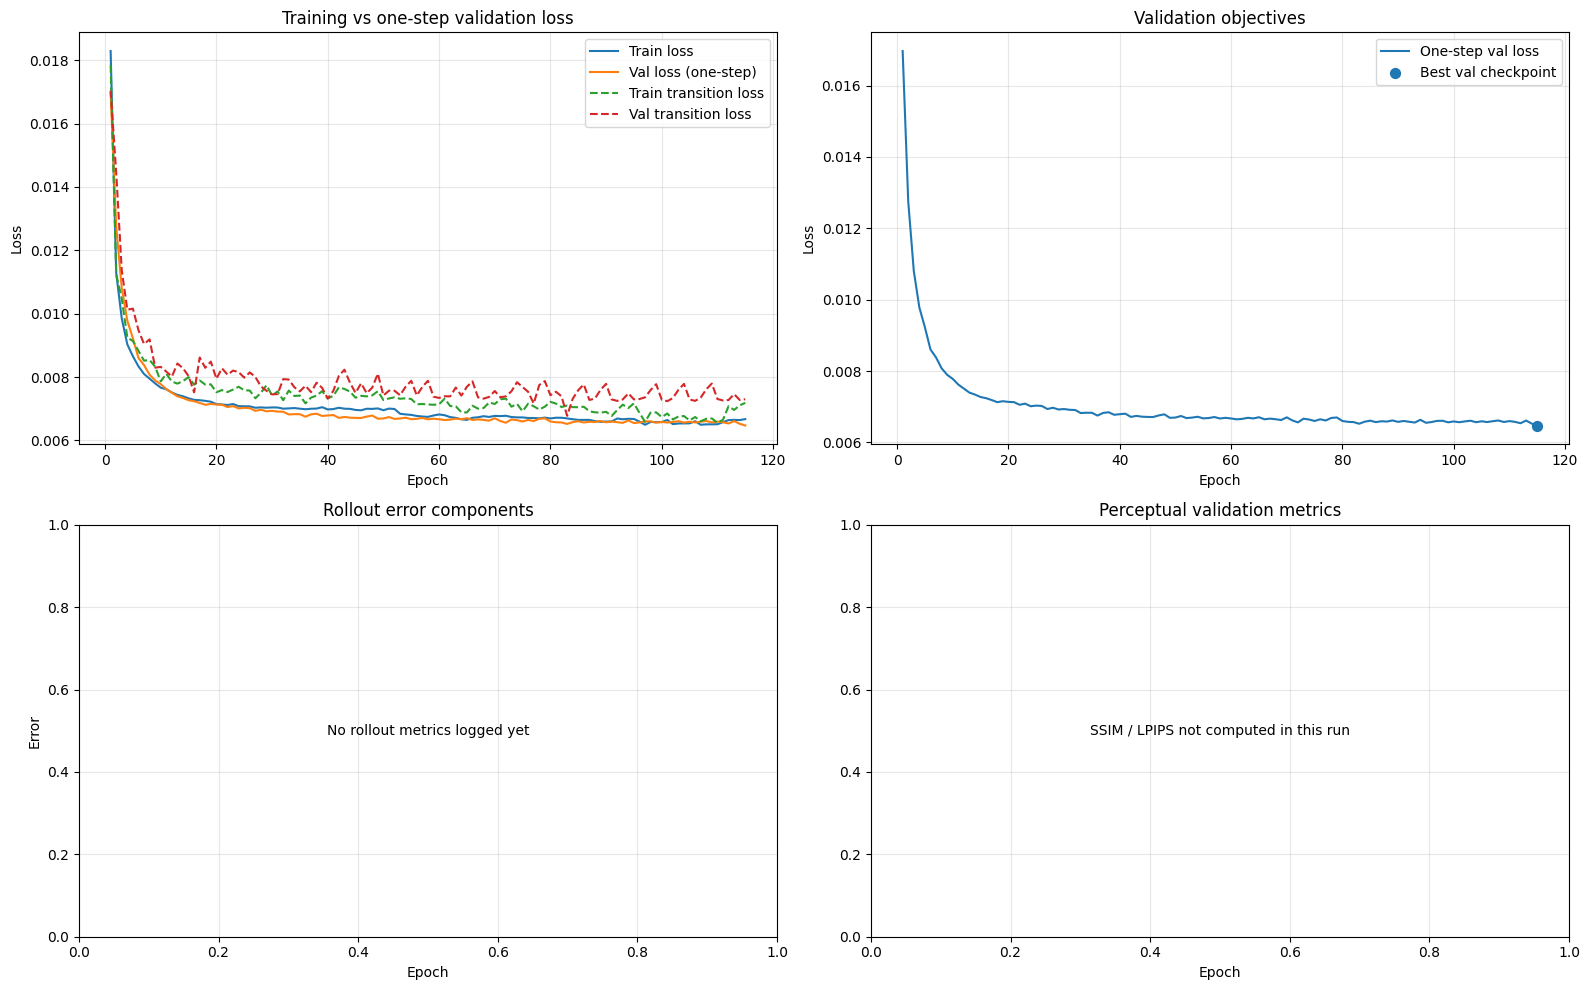

In [25]:

# Plot train/val loss, rollout error, and perceptual metrics
history_for_plot = globals().get('metric_history', [])
if METRIC_HISTORY_PATH.exists():
    try:
        with open(METRIC_HISTORY_PATH, 'r', encoding='utf-8') as f:
            history_for_plot = json.load(f)
    except Exception as exc:
        print(f"WARNING: failed to load {METRIC_HISTORY_PATH}: {exc}")

if history_for_plot:
    epochs = np.array([m.get('epoch', i + 1) for i, m in enumerate(history_for_plot)], dtype=float)
    train_loss = np.array([m.get('train_loss', np.nan) for m in history_for_plot], dtype=float)
    val_loss = np.array([m.get('val_loss', np.nan) for m in history_for_plot], dtype=float)
    train_transition_loss = np.array([m.get('train_transition_loss', np.nan) if m.get('train_transition_loss') is not None else np.nan for m in history_for_plot], dtype=float)
    val_transition_loss = np.array([m.get('val_transition_loss', np.nan) if m.get('val_transition_loss') is not None else np.nan for m in history_for_plot], dtype=float)
    rollout_loss = np.array([m.get('val_rollout_loss', np.nan) for m in history_for_plot], dtype=float)
    rollout_mse = np.array([m.get('val_rollout_mse', np.nan) for m in history_for_plot], dtype=float)
    rollout_l1 = np.array([m.get('val_rollout_l1', np.nan) for m in history_for_plot], dtype=float)
    transition_rollout_loss = np.array([m.get('val_transition_rollout_loss', np.nan) if m.get('val_transition_rollout_loss') is not None else np.nan for m in history_for_plot], dtype=float)
    val_ssim = np.array([m.get('val_ssim', np.nan) if m.get('val_ssim') is not None else np.nan for m in history_for_plot], dtype=float)
    val_lpips = np.array([m.get('val_lpips', np.nan) if m.get('val_lpips') is not None else np.nan for m in history_for_plot], dtype=float)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    axes[0, 0].plot(epochs, train_loss, label='Train loss')
    axes[0, 0].plot(epochs, val_loss, label='Val loss (one-step)')
    if np.isfinite(train_transition_loss).any():
        axes[0, 0].plot(epochs, train_transition_loss, label='Train transition loss', linestyle='--')
    if np.isfinite(val_transition_loss).any():
        axes[0, 0].plot(epochs, val_transition_loss, label='Val transition loss', linestyle='--')
    axes[0, 0].set_title('Training vs one-step validation loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    axes[0, 1].plot(epochs, val_loss, label='One-step val loss')
    if np.isfinite(rollout_loss).any():
        axes[0, 1].plot(epochs, rollout_loss, label=f'Rollout H={VAL_ROLLOUT_STEPS} loss')
        best_rollout_idx = int(np.nanargmin(rollout_loss))
        axes[0, 1].scatter(epochs[best_rollout_idx], rollout_loss[best_rollout_idx], s=50, label='Best rollout checkpoint')
    if np.isfinite(transition_rollout_loss).any():
        axes[0, 1].plot(epochs, transition_rollout_loss, label=f'Transition rollout H={VAL_ROLLOUT_STEPS} loss', linestyle='--')
    best_val_idx = int(np.nanargmin(val_loss))
    axes[0, 1].scatter(epochs[best_val_idx], val_loss[best_val_idx], s=50, label='Best val checkpoint')
    axes[0, 1].set_title('Validation objectives')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    if np.isfinite(rollout_mse).any():
        axes[1, 0].plot(epochs, rollout_mse, label=f'Rollout H={VAL_ROLLOUT_STEPS} MSE')
    if np.isfinite(rollout_l1).any():
        axes[1, 0].plot(epochs, rollout_l1, label=f'Rollout H={VAL_ROLLOUT_STEPS} L1')
    axes[1, 0].set_title('Rollout error components')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Error')
    axes[1, 0].grid(True, alpha=0.3)
    if axes[1, 0].lines:
        axes[1, 0].legend()
    else:
        axes[1, 0].text(0.5, 0.5, 'No rollout metrics logged yet', ha='center', va='center', transform=axes[1, 0].transAxes)

    has_perceptual = False
    if np.isfinite(val_ssim).any():
        axes[1, 1].plot(epochs, val_ssim, label='Val SSIM')
        has_perceptual = True
    if np.isfinite(val_lpips).any():
        axes[1, 1].plot(epochs, val_lpips, label='Val LPIPS')
        has_perceptual = True
    axes[1, 1].set_title('Perceptual validation metrics')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].grid(True, alpha=0.3)
    if has_perceptual:
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, 'SSIM / LPIPS not computed in this run', ha='center', va='center', transform=axes[1, 1].transAxes)

    plt.tight_layout()
    plt.show()
else:
    print('No metrics logged yet.')


## 13. Inference Helpers
Utilities for one-step prediction and multi-step rollouts from user-provided context paths.
Rollouts follow the plane inferred from the context file paths for naming/visualization only.


In [ ]:
# ---- Low-level path / context helpers ----

def _expected_context_channels() -> int:
    """Return the number of context frames the loaded diffusion model expects."""
    return int(getattr(diffusion, 'context_k', MODEL_CONTEXT_K))


def _stack_context_paths(context_paths: list[str]) -> torch.Tensor:
    """Load grayscale frames from disk and stack into a [1, k, H, W] tensor."""
    imgs = [load_image(p) for p in context_paths]  # each [1, H, W]
    return torch.stack([img.squeeze(0) for img in imgs], dim=0).unsqueeze(0)


def _infer_frame_index(path: str) -> int | None:
    """Extract the 1-based frame number from a silver dataset filename (e.g. 00037.jpeg → 37)."""
    m = re.search(r"(\d+)\.jpe?g$", Path(path).name)
    return int(m.group(1)) if m else None


def _infer_context_plane(context_paths: list[str]) -> str:
    """Infer focal plane from context paths and validate single-plane consistency."""
    inferred = [
        part
        for p in context_paths
        for part in Path(p).parts
        if part in FOCAL_PLANE_SET
    ]
    if not inferred:
        raise ValueError(
            'Could not infer focal plane from context paths. '
            'Expected each path to include a focal-plane folder (e.g. F0, F-15, …).'
        )
    plane = inferred[-1]
    if any(pl != plane for pl in inferred):
        raise ValueError('All context paths must be from the same focal plane.')
    return plane


def _initial_phase_seq_from_paths(context_paths: list[str]) -> torch.Tensor | None:
    """Classify context frames to build an initial phase sequence for ad-hoc rollouts."""
    if not USE_CLASSIFIER_PHASE_POLICY:
        return None
    return infer_phase_sequence_from_context_paths(context_paths)


# ---- User-facing inference functions ----

def visualize_samples(num: int = 4, plane: str = 'F0', save_dir=None):
    """Generate and save the same sample grids as during training: mixed, transition, and rollout.

    Args:
        num: number of samples per category.
        plane: focal plane to sample from.
        save_dir: output directory (defaults to OUT_SAMPLES_DIR/ad_hoc_samples/<plane>).
    """
    if save_dir is None:
        save_dir = OUT_SAMPLES_DIR / 'ad_hoc_samples' / plane
    save_dir = Path(save_dir)

    mixed_dir = save_dir / 'mixed'
    transitions_dir = save_dir / 'transitions'
    rollouts_dir = save_dir / 'rollouts'
    for d in (mixed_dir, transitions_dir, rollouts_dir):
        d.mkdir(parents=True, exist_ok=True)

    samples = val_dataset.sample_pairs_for_plane(plane, num)
    if samples:
        _save_sample_grid(samples, mixed_dir, title_suffix='(mixed)')

    trans_samples = val_dataset.sample_transition_pairs_for_plane(plane, num)
    if trans_samples:
        _save_sample_grid(trans_samples, transitions_dir, title_suffix='(transition)')

    if ENABLE_ROLLOUT_GRIDS:
        for stale_path in rollouts_dir.glob('*gen_t*.png'):
            stale_path.unlink()
        rollout_seed = val_dataset.sample_pairs_for_plane(plane, 1)
        if rollout_seed:
            _save_rollout_grid(rollout_seed[0], rollouts_dir, steps=ROLLOUT_GRID_STEPS)

    if USE_CLASSIFIER_PHASE_POLICY:
        unload_phase_classifier()
    print(f"Ad hoc samples saved to {save_dir}")


def predict_next_frame(context_paths: list[str], out_path: str, max_frame_index: int | None = None) -> dict[str, str]:
    """One-step next-frame prediction from the same focal plane as the provided context.

    Args:
        context_paths: exactly k paths to the most recent context frames (ascending frame order).
        out_path: base output path; the plane name is appended before the extension.
        max_frame_index: override for the time-conditioning cap (default: MAX_FRAME_INDEX).

    Returns:
        Dict mapping plane name → saved image path.
    """
    expected_k = _expected_context_channels()
    if len(context_paths) != expected_k:
        raise ValueError(f"Need exactly {expected_k} context frames, got {len(context_paths)}")

    plane_name = _infer_context_plane(context_paths)
    x_ctx = _stack_context_paths(context_paths).to(device)

    frame_cap = int(MAX_FRAME_INDEX if max_frame_index is None else max_frame_index)
    if frame_cap <= 0:
        raise ValueError(f"max_frame_index must be positive, got {frame_cap}")

    frame_idx = None
    if USE_TIME_MAP:
        t_end = _infer_frame_index(context_paths[-1]) or 0
        frame_idx = torch.tensor([min(t_end + 1, frame_cap)], device=device, dtype=torch.long)

    out_ch = _target_channels()
    x_gen = sample_from_model((1, out_ch, IMG_SIZE, IMG_SIZE), x_ctx=x_ctx, frame_idx=frame_idx)

    stem = Path(out_path).with_suffix('')
    plane_path = stem.parent / f"{stem.name}_{plane_name}.png"
    save_tensor_image(x_gen[0, 0], plane_path)
    return {plane_name: str(plane_path)}


def rollout_next_frames(
    initial_context_paths: list[str],
    steps: int,
    out_dir: str,
    max_frame_index: int | None = None,
    initial_phase_seq: list[int] | None = None,
) -> list[dict]:
    """Multi-step autoregressive rollout for the focal plane of the provided context.

    Args:
        initial_context_paths: exactly k paths to seed context frames (ascending frame order).
        steps: number of frames to generate autoregressively.
        out_dir: directory for generated frames.
        max_frame_index: time-conditioning cap (default: MAX_FRAME_INDEX).
        initial_phase_seq: list of k phase IDs for the initial context (auto-inferred if None).

    Returns:
        List of per-step dicts with 't_frame', 'path', 'images', and 'phase_ids'.
    """
    expected_k = _expected_context_channels()
    if len(initial_context_paths) != expected_k:
        raise ValueError(f"Need exactly {expected_k} context frames, got {len(initial_context_paths)}")

    plane_name = _infer_context_plane(initial_context_paths)
    ctx_tensors = [load_image(p) for p in initial_context_paths]
    frame_candidates = [f for f in (_infer_frame_index(p) for p in initial_context_paths) if f is not None]
    t_end = max(frame_candidates) if frame_candidates else 0

    phase_seq_tensor = None
    if initial_phase_seq is not None:
        if len(initial_phase_seq) != expected_k:
            raise ValueError(f"initial_phase_seq must have length {expected_k}")
        phase_seq_tensor = torch.tensor([initial_phase_seq], device=device, dtype=torch.long)
    elif USE_CLASSIFIER_PHASE_POLICY:
        inferred = _initial_phase_seq_from_paths(initial_context_paths)
        if inferred is not None:
            phase_seq_tensor = inferred.to(device=device, dtype=torch.long)

    frame_cap = int(MAX_FRAME_INDEX if max_frame_index is None else max_frame_index)
    return _run_rollout(
        ctx_tensors=ctx_tensors,
        t_end=t_end,
        steps=steps,
        out_dir=Path(out_dir),
        phase_seq_tensor=phase_seq_tensor,
        frame_index_cap=frame_cap,
        plane_name=plane_name,
    )
